# Non-Separable Time and Graph Gaussian Processes with a Kronecker-Sum HSGP

In many forecasting problems the data come as a panel: one weekly series per region, for many regions. The regions share a slow national trend. The regional deviations from that trend are not independent: neighboring regions move together, and rough spatial patterns (one region up, its neighbor down) do not last as long as smooth ones. We want a prior on the latent panel that encodes these three facts and that is cheap enough to run inside a full Bayesian workflow.

The Hilbert space Gaussian process (HSGP) approximation gives us a fixed basis and diagonal weights for a stationary kernel on an interval. In this notebook we extend that construction to the product space *interval times graph*. The key observation is that the natural Laplacian on the product is a Kronecker sum, whose eigenpairs are products of the eigenpairs of the two factors with eigenvalues that *add*. Evaluating a Matérn spectral density at the *sum* of the eigenvalues gives a non-separable spatio-temporal kernel, and the HSGP computational structure survives: a hyperparameter-free basis, diagonal weights, and two matrix multiplications.

Concretely, we do the following:

- We build the basis on the time box and the eigenbasis of the graph Laplacian, and we combine them into three priors that share the same hyperparameters: independent regions, a separable (product) kernel, and the Kronecker-sum kernel.
- We simulate a weekly panel for the 16 German states with a data generating process that is deliberately *not* the model.
- We fit the three models with NUTS in [NumPyro](https://num.pyro.ai/), forecast 13 weeks ahead with [`numpyro-forecast`](https://github.com/juanitorduz/numpyro_forecast), and compare the forecasts with the CRPS.
- We run a rolling-origin backtest to check that the ranking is not an artifact of a single split.

We assume the reader knows the basics of the HSGP approximation (see [A Conceptual and Practical Introduction to Hilbert Space GPs Approximation Methods](https://juanitorduz.github.io/hsgp_intro/) and [Riutort-Mayol et al. (2023)](https://link.springer.com/article/10.1007/s11222-022-10167-2)) and what a graph Laplacian is (see [Spectral Clustering](https://juanitorduz.github.io/spectral_clustering/)).

**Remark.** The gain of the non-separable kernel over the separable one is modest and depends on the data. The value of this notebook is the construction itself, and the checks that go with it: normalization, node standardization, basis size, and the time box.

## Prepare Notebook

We tell JAX to expose four host devices before it initializes its backend, so that the four NUTS chains run in parallel.

In [1]:
import numpyro

numpyro.set_host_device_count(n=4)

In [2]:
import time
from typing import Literal

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import numpyro.distributions as dist
import polars as pl
from jax import random
from jaxtyping import Array, Float
from numpyro.contrib.hsgp.laplacian import eigenfunctions, sqrt_eigenvalues
from numpyro.handlers import do, substitute
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from numpyro_forecast import (
    Horizon,
    backtest,
    eval_coverage,
    eval_crps,
    eval_rmse,
    forecast,
    predict,
)
from numpyro_forecast.features import fourier_features

seed: int = 42
rng_key = random.PRNGKey(seed=seed)

HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"

## The Problem and the Estimand

We observe a panel $y_{t, r}$ for weeks $t = 1, \ldots, T$ and regions $r = 1, \ldots, R$. The regions are the nodes of an undirected graph with adjacency matrix $A$ (two regions are adjacent if they share a border). We want to forecast $H$ weeks ahead for every region.

The estimand is the predictive distribution $\text{P}(y_{T + h, r} \mid y_{1:T, 1:R})$ for $h = 1, \ldots, H$ and every $r$. We compare priors on the latent panel by the quality of this predictive distribution, measured with the continuous ranked probability score (CRPS), the root mean squared error (RMSE) of the mean forecast, and the empirical coverage of the central $90\%$ interval.

All models share the same observation equation. Let $f(t, r)$ be a latent Gaussian process on the product space, $a_r$ a regional intercept, $s(t)$ a yearly seasonal term, and $\sigma$ the observation scale:

$$
y_{t, r} = a_r + f(t, r) + s(t) + \varepsilon_{t, r}, \qquad \varepsilon_{t, r} \sim \text{StudentT}(\nu_{\varepsilon}, 0, \sigma).
$$

The three models differ only in the prior on $f$.

## From the Interval to the Product Space

### HSGP on an Interval

A stationary kernel $k(t, t') = k(t - t')$ on the real line is a function of the Laplacian: $K = S(\sqrt{-\Delta})$, where $S$ is the spectral density of the kernel. The HSGP approximation restricts the Laplacian to the box $[-L, L]$ with Dirichlet boundary conditions, whose eigenpairs are known in closed form. Let $m$ be the number of basis functions, $j = 1, \ldots, m$, and $\omega_j = j \pi / (2L)$. The eigenfunctions and eigenvalues are

$$
\phi_j(t) = \frac{1}{\sqrt{L}} \sin\left(\omega_j (t + L)\right), \qquad \lambda_j = \omega_j^2 .
$$

The approximate process is $f(t) = \sum_j \sqrt{S(\sqrt{\lambda_j})}\, \beta_j\, \phi_j(t)$ with $\beta_j \sim \text{Normal}(0, 1)$. The basis does not depend on the kernel hyperparameters; only the weights $S(\sqrt{\lambda_j})$ do.

For forecasting, the box must contain the training window *and* the forecast horizon. With $D = T + H$ time steps we center the grid and set $L = c\, (D - 1) / 2$ with $c > 1$ (we use $c = 1.5$).

### The Graph Laplacian

Let $D_G$ be the diagonal matrix of node degrees. The graph Laplacian is $L_G = D_G - A$. It is symmetric and positive semidefinite, so it has an orthonormal eigendecomposition $L_G = U \operatorname{diag}(\mu) U^\top$ with eigenvalues $0 = \mu_0 \le \mu_1 \le \cdots \le \mu_{R - 1}$ and eigenvectors $u_v$ (the columns of $U$). The first eigenvector $u_0$ is constant: it is the *national average* mode. Eigenvectors with larger $\mu_v$ oscillate faster over the graph, in the same sense that $\sin(\omega_j t)$ oscillates faster for larger $j$.

A Matérn Gaussian process on a graph ([Borovitskiy et al., 2021](https://proceedings.mlr.press/v130/borovitskiy21a.html)) is defined by the same recipe as on the interval: a spectral density evaluated at the Laplacian eigenvalues, $K_G = \sum_v S(\sqrt{\mu_v})\, u_v u_v^\top$.

### The Kronecker Sum

On the product space *interval times graph* the natural Laplacian is the Kronecker sum $-\Delta_t \oplus L_G$. Its eigenpairs are products of the factor eigenpairs, and the eigenvalues *add*:

$$
\left(\lambda_j + \mu_v,\; \phi_j(t)\, u_v(r)\right), \qquad j = 1, \ldots, m, \quad v = 0, \ldots, R - 1 .
$$

We evaluate a Matérn spectral density at the sum. Let $\nu$ be the Matérn smoothness, $\ell$ the temporal lengthscale, $\kappa^2 = 2\nu / \ell^2$, and $\rho \ge 0$ a dimensionless scale that converts graph eigenvalues into the units of $\lambda$. The spectral weights are

$$
W_{j v} = C \left(\kappa^2 + \lambda_j + \kappa^2 \rho\, \mu_v\right)^{-(\nu + 1/2)}
        = C' \left(1 + \frac{\lambda_j}{\kappa^2} + \rho\, \mu_v\right)^{-(\nu + 1/2)} ,
$$

and the process is

$$
f(t, r) = \sum_{j, v} \sqrt{W_{j v}}\, \beta_{j v}\, \phi_j(t)\, u_v(r), \qquad \beta_{j v} \sim \text{Normal}(0, 1).
$$

In matrix form, with $\Phi$ the $T \times m$ matrix of time basis functions and $B$ the $m \times R$ matrix of coefficients, $F = \Phi\, (\sqrt{W} \circ B)\, U^\top$: two matrix multiplications.

**Interpretation.** Fix a graph mode $v$ and look at the weights as a function of $j$ only. They are the weights of a one-dimensional Matérn-$\nu$ process in time with inverse squared lengthscale $\kappa^2 (1 + \rho \mu_v)$. So graph mode $v$ has effective temporal lengthscale and (after summing over $j$) variance

$$
\ell_v = \frac{\ell}{\sqrt{1 + \rho\, \mu_v}}, \qquad \text{Var}_v \propto (1 + \rho\, \mu_v)^{-\nu} .
$$

Three consequences follow:

- $v = 0$ is the shared national trend, with the longest lengthscale $\ell$ and the largest variance.
- Rough spatial patterns (large $\mu_v$) have shorter memory and smaller amplitude.
- $\rho \to 0$ makes all modes identical (independent regions with shared hyperparameters); $\rho \to \infty$ leaves only $v = 0$ (complete pooling).

So $\rho$ is a single *spatial pooling strength*, and the graph decides which deviations are suppressed first. For a forecast this means that regional forecasts shrink toward the national forecast at a rate that increases with the horizon and with spatial roughness.

### Three Priors with the Same Hyperparameters

To attribute a difference in forecast quality to non-separability alone, we compare three priors that share $(\sigma_f, \ell, \rho)$ and differ only in how the two spectra are combined:

| mode | $W_{jv}$ | kernel |
|---|---|---|
| `kron_sum` | $(1 + \lambda_j / \kappa^2 + \rho \mu_v)^{-(\nu + 1/2)}$ | non-separable |
| `separable` | $(1 + \lambda_j / \kappa^2)^{-(\nu + 1/2)}\, (1 + \rho \mu_v)^{-(\nu + 1/2)}$ | Matérn(time) $\otimes$ graph-Matérn |
| `independent` | $(1 + \lambda_j / \kappa^2)^{-(\nu + 1/2)}$ with $U = I$ | one HSGP per region |

The separable kernel is the product of a temporal Matérn kernel and a graph Matérn kernel (an intrinsic coregionalization model with a fixed coregionalization matrix). In the separable kernel every graph mode has the *same* temporal lengthscale; the graph only changes the amplitude of each mode.

### Normalization and Node Standardization

We fix the overall scale by trace normalization. Since $\sum_r u_v(r)^2 = 1$ and the average of $\phi_j(t)^2$ over the box is $1 / (2L)$, the average prior variance over time and regions is $\sum_{j v} W_{j v} / (2 L R)$. We choose $C'$ so that this average equals $\sigma_f^2$.

Graph Matérn priors have a marginal variance that depends on the node: on the German adjacency graph the prior variance at Bremen (degree 1) and at Lower Saxony (degree 9) differ by a factor of about four. This is an accident of the adjacency, not a modeling statement. Let $v_r = \sum_{j v} W_{j v}\, u_v(r)^2 / (2L)$ be the prior variance at region $r$. We rescale $f(\cdot, r)$ by $s_r = \sigma_f / \sqrt{v_r}$. With $D = \operatorname{diag}(s)$ the kernel becomes $D K D$, which is still positive semidefinite and still two matrix multiplications (we replace $U$ by $D U$). Every region then has prior variance $\sigma_f^2$ and the graph only shapes the *correlations*.

### Basis Size

The number of time basis functions $m$ must resolve the *shortest* effective lengthscale, $\ell_{\min} = \ell / \sqrt{1 + \rho\, \mu_{\max}}$, not $\ell$. The rule of thumb of Riutort-Mayol et al. for a Matérn-$3/2$ kernel becomes $m \gtrsim 1.75\, c\, (D / 2) / \ell_{\min}$. If $m$ is too small the truncation silently over-smooths the rough spatial modes, which acts like a larger $\rho$. We check this rule against the posterior later in the notebook.

## The Graph

We use the adjacency graph of the 16 German states (Bundesländer). Two states are adjacent if they share a land border.

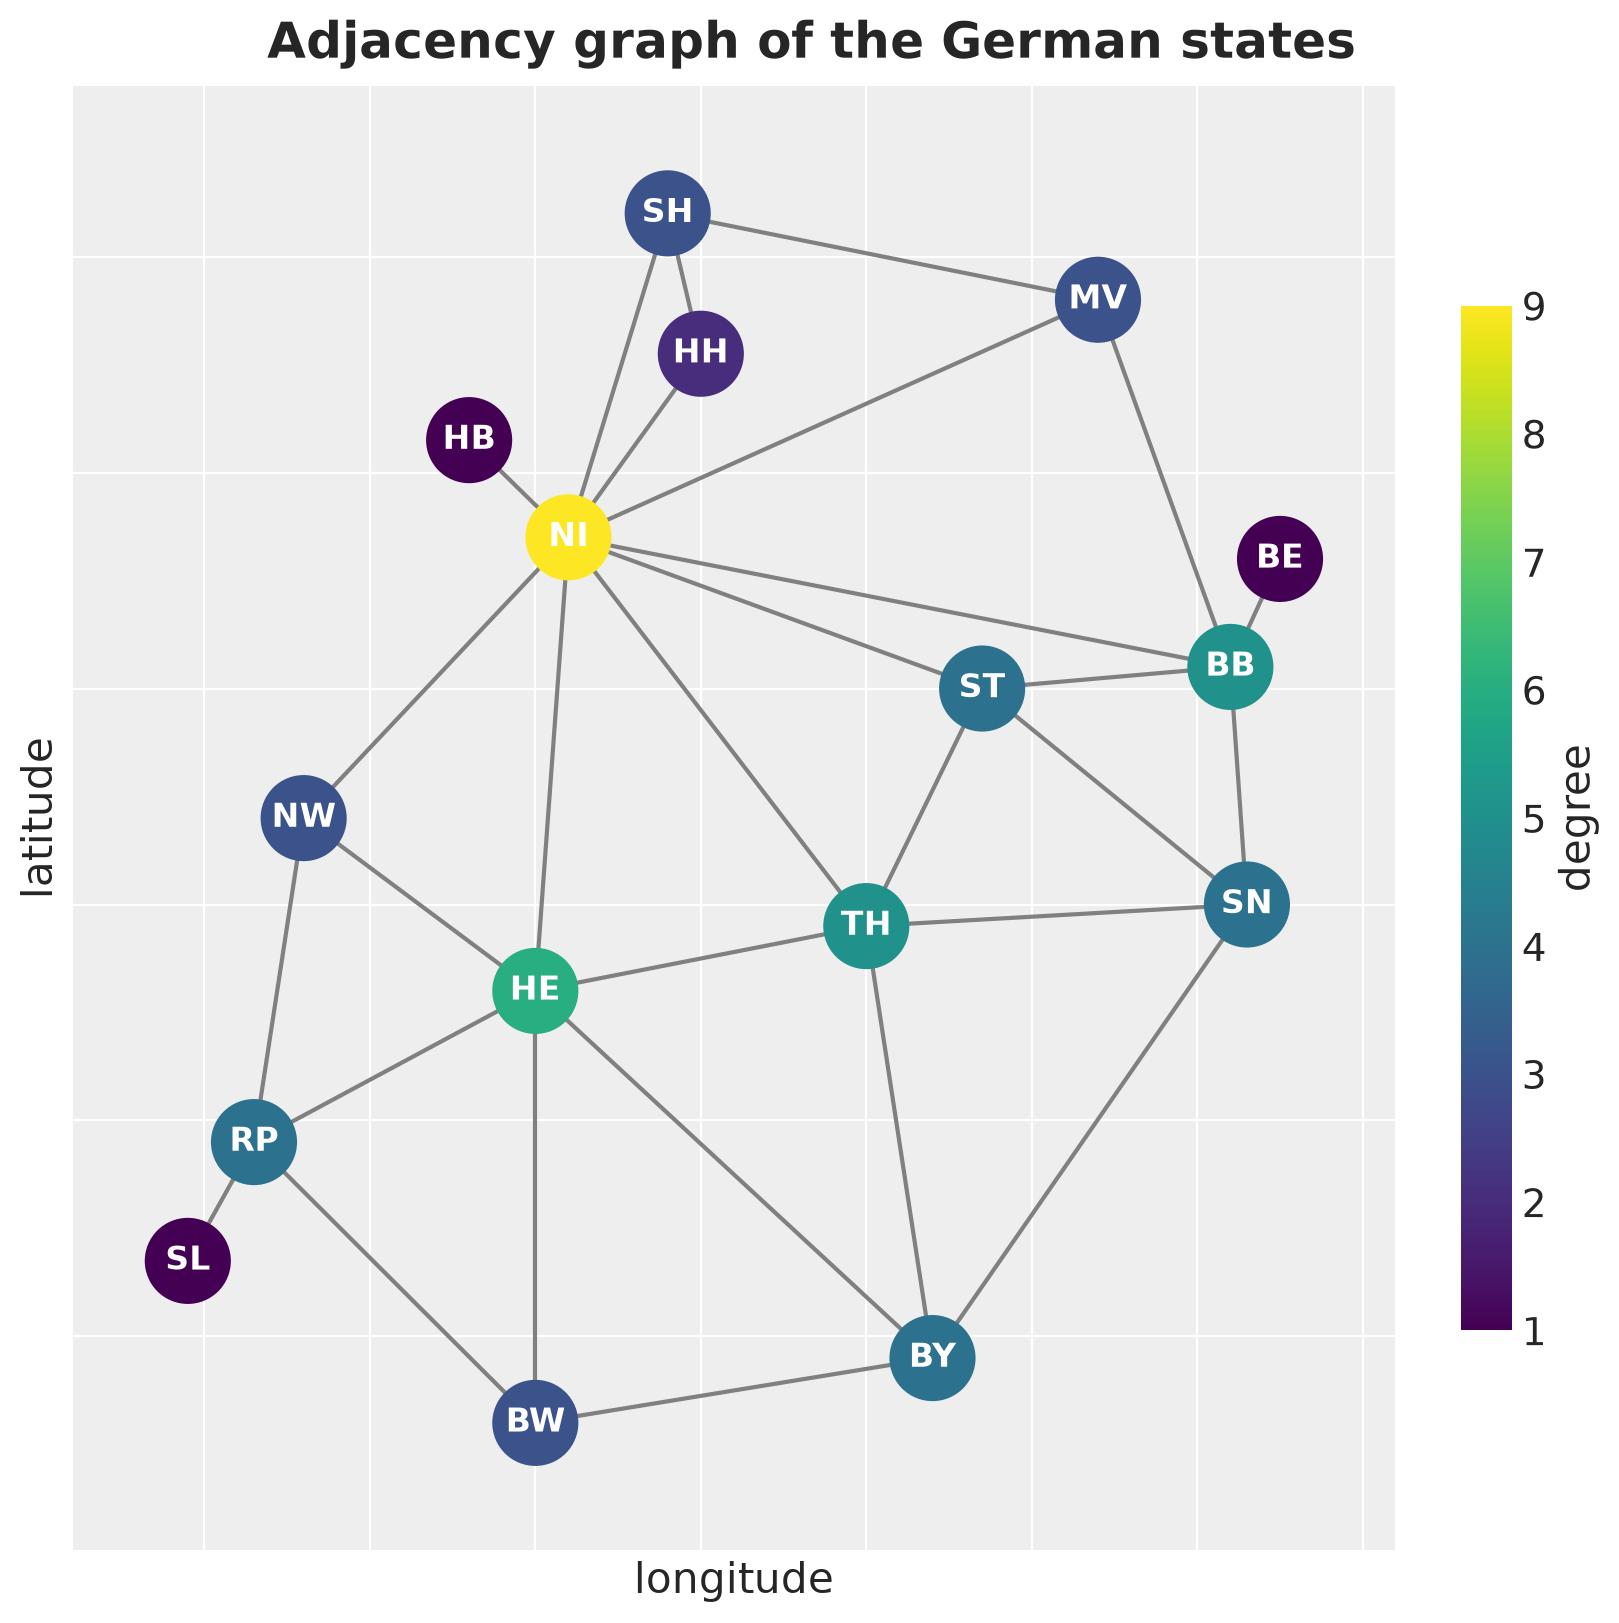

In [3]:
STATES = [
    "SH",
    "HH",
    "NI",
    "HB",
    "NW",
    "HE",
    "RP",
    "BW",
    "BY",
    "SL",
    "BE",
    "BB",
    "MV",
    "SN",
    "ST",
    "TH",
]

EDGES = [
    ("SH", "HH"),
    ("SH", "NI"),
    ("SH", "MV"),
    ("HH", "NI"),
    ("NI", "HB"),
    ("NI", "NW"),
    ("NI", "HE"),
    ("NI", "TH"),
    ("NI", "ST"),
    ("NI", "BB"),
    ("NI", "MV"),
    ("NW", "HE"),
    ("NW", "RP"),
    ("HE", "RP"),
    ("HE", "BW"),
    ("HE", "BY"),
    ("HE", "TH"),
    ("RP", "BW"),
    ("RP", "SL"),
    ("BW", "BY"),
    ("BY", "TH"),
    ("BY", "SN"),
    ("BE", "BB"),
    ("BB", "MV"),
    ("BB", "ST"),
    ("BB", "SN"),
    ("SN", "TH"),
    ("SN", "ST"),
    ("ST", "TH"),
]

# approximate (longitude, latitude) of each state, used only for the layout of the plots
POSITIONS = {
    "SH": (9.8, 54.2),
    "HH": (10.0, 53.55),
    "NI": (9.2, 52.7),
    "HB": (8.6, 53.15),
    "NW": (7.6, 51.4),
    "HE": (9.0, 50.6),
    "RP": (7.3, 49.9),
    "BW": (9.0, 48.6),
    "BY": (11.4, 48.9),
    "SL": (6.9, 49.35),
    "BE": (13.5, 52.6),
    "BB": (13.2, 52.1),
    "MV": (12.4, 53.8),
    "SN": (13.3, 51.0),
    "ST": (11.7, 52.0),
    "TH": (11.0, 50.9),
}

R = len(STATES)
state_index = {s: i for i, s in enumerate(STATES)}

adjacency = np.zeros((R, R))
for a, b in EDGES:
    adjacency[state_index[a], state_index[b]] = adjacency[
        state_index[b], state_index[a]
    ] = 1.0

graph = nx.Graph(EDGES)
degree = adjacency.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
nodes = nx.draw_networkx_nodes(
    graph,
    pos=POSITIONS,
    nodelist=STATES,
    node_color=degree,
    cmap="viridis",
    node_size=900,
    ax=ax,
)
nx.draw_networkx_edges(graph, pos=POSITIONS, edge_color="gray", width=1.5, ax=ax)
nx.draw_networkx_labels(
    graph, pos=POSITIONS, font_color="white", font_weight="bold", ax=ax
)
fig.colorbar(nodes, ax=ax, label="degree", shrink=0.7)
ax.set(xlabel="longitude", ylabel="latitude")
fig.suptitle("Adjacency graph of the German states", fontsize=18, fontweight="bold");

The graph is irregular: Lower Saxony (NI) has nine neighbors, Bremen (HB) has one. We compute the Laplacian and its eigendecomposition once, outside any model. We clip tiny negative eigenvalues from round-off and set $\mu_0 = 0$ exactly.

In [4]:
def graph_laplacian(adjacency: np.ndarray) -> np.ndarray:
    "Combinatorial graph Laplacian L = D - A of a symmetric adjacency matrix."
    if not np.allclose(adjacency, adjacency.T):
        raise ValueError("adjacency must be symmetric")
    return np.diag(adjacency.sum(axis=1)) - adjacency


def laplacian_eigenpairs(adjacency: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    "Ascending eigenvalues mu (mu[0] = 0) and eigenvectors U (columns)."
    mu, U = np.linalg.eigh(graph_laplacian(adjacency))
    mu = np.clip(mu, 0.0, None)
    mu[0] = 0.0
    return mu, U


mu, U = laplacian_eigenpairs(adjacency)

mode_names = [f"mode {v}" for v in range(R)]

pl.DataFrame({"mu": mu.round(3)}).transpose(
    include_header=True, header_name="quantity", column_names=mode_names
)

quantity,mode 0,mode 1,mode 2,mode 3,mode 4,mode 5,mode 6,mode 7,mode 8,mode 9,mode 10,mode 11,mode 12,mode 13,mode 14,mode 15
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""mu""",0.0,0.514,0.788,1.021,1.107,1.841,2.388,2.708,3.894,4.214,4.856,5.117,5.931,6.189,7.246,10.185


The first eigenvector is constant. The second one (the Fiedler vector) splits the graph into two smooth halves. Higher modes oscillate faster over the graph.

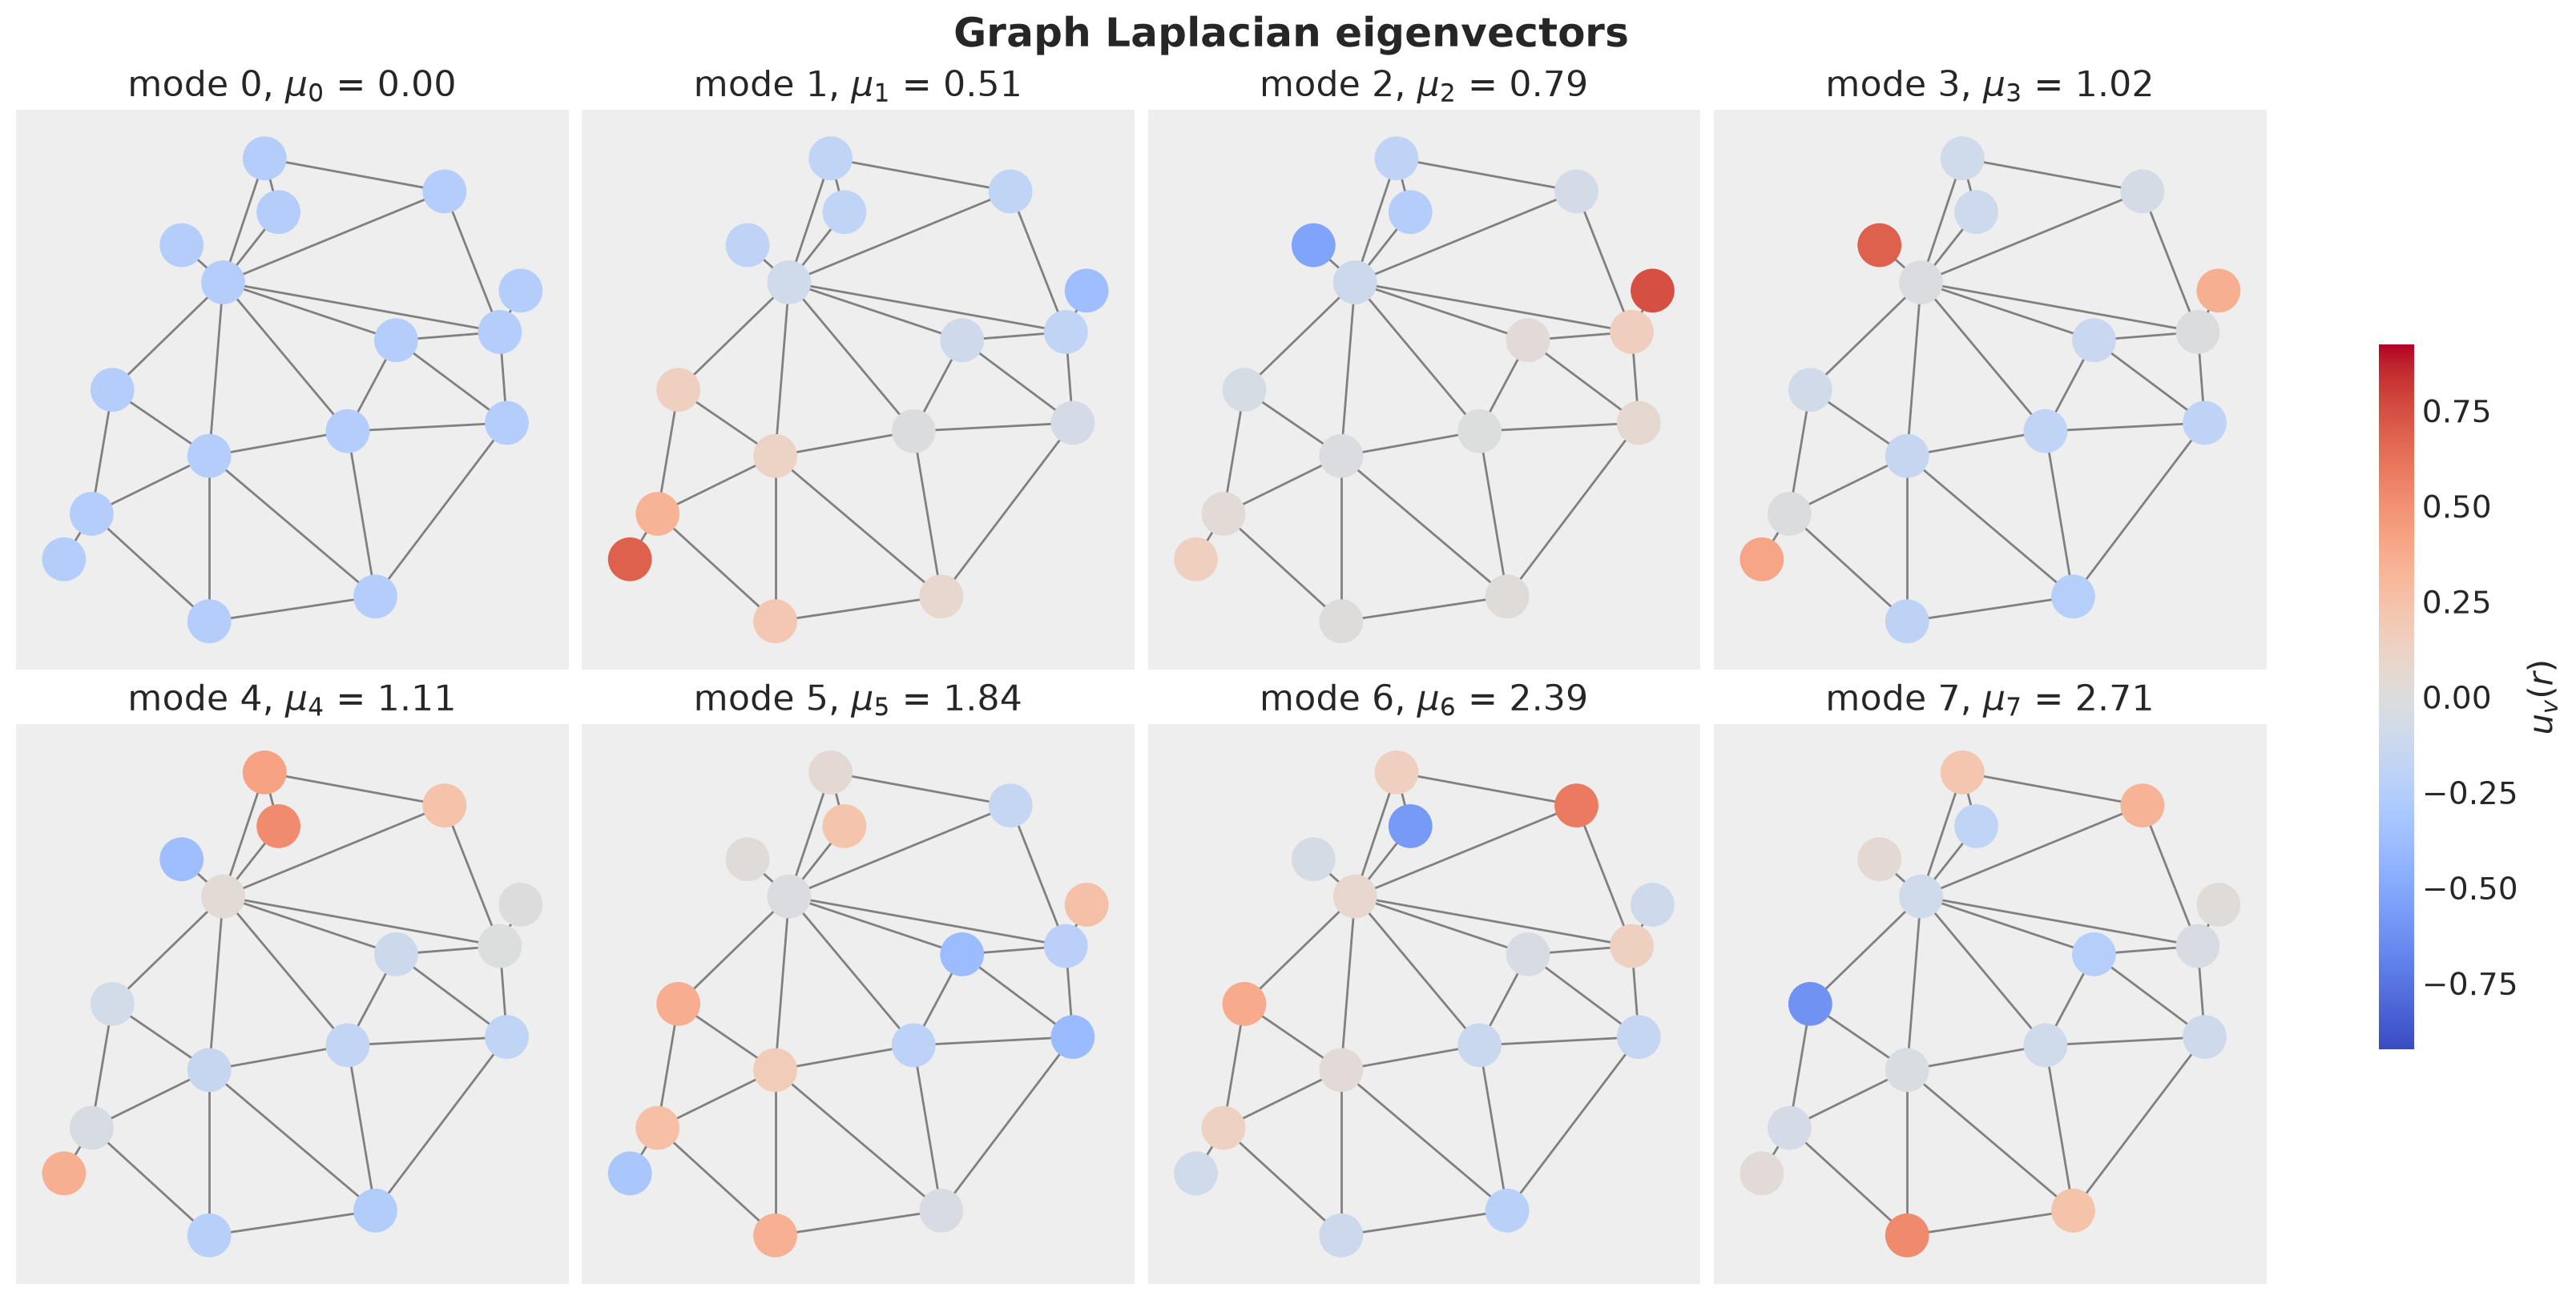

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8), layout="constrained")
vmax = np.abs(U).max()
for v, ax in enumerate(axes.flat):
    nodes = nx.draw_networkx_nodes(
        graph,
        pos=POSITIONS,
        nodelist=STATES,
        node_color=U[:, v],
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        node_size=350,
        ax=ax,
    )
    nx.draw_networkx_edges(graph, pos=POSITIONS, edge_color="gray", ax=ax)
    ax.set(title=f"mode {v}, $\\mu_{{{v}}}$ = {mu[v]:.2f}", xticks=[], yticks=[])
fig.colorbar(nodes, ax=axes, label="$u_v(r)$", shrink=0.6)
fig.suptitle("Graph Laplacian eigenvectors", fontsize=18, fontweight="bold");

## Building Blocks

We now write the construction as a few small functions. The time side uses the HSGP basis of `numpyro.contrib.hsgp` on a centered box. The graph side is the eigendecomposition above. The only place where the three models differ is `spectral_weights`.

In [6]:
Mode = Literal["kron_sum", "separable", "independent"]


def time_box(duration: int, c: float = 1.5) -> tuple[Float[Array, " duration"], float]:
    "Centered time grid and the box half-width c * (duration - 1) / 2."
    t = jnp.arange(duration, dtype=jnp.float32)
    half = (duration - 1) / 2.0
    return t - half, float(c * half)


def time_basis(
    t_c: Float[Array, " duration"], ell_box: float, m: int
) -> tuple[Float[Array, "duration m"], Float[Array, " m"]]:
    "HSGP sine basis Phi (duration, m) and eigenvalues lambda (m,) on the box."
    phi = eigenfunctions(t_c, ell=ell_box, m=m)
    lam = sqrt_eigenvalues(ell_box, m, dim=1)[0] ** 2
    return phi, lam


def spectral_weights(
    lam: Float[Array, " m"],
    mu: Float[Array, " R"],
    *,
    mode: Mode,
    nu: float,
    length: Float[Array, ""],
    rho: Float[Array, ""],
    sigma_f: Float[Array, ""],
    ell_box: float,
) -> Float[Array, "m R"]:
    "Trace-normalized spectral weights W[j, v] for the three constructions."
    kappa2 = 2.0 * nu / length**2
    power = -(nu + 0.5)
    lam_ = lam[:, None]
    mu_ = mu[None, :]
    if mode == "kron_sum":
        w = (1.0 + lam_ / kappa2 + rho * mu_) ** power
    elif mode == "separable":
        w = (1.0 + lam_ / kappa2) ** power * (1.0 + rho * mu_) ** power
    elif mode == "independent":
        w = jnp.broadcast_to(
            (1.0 + lam_ / kappa2) ** power, (lam.shape[0], mu.shape[0])
        )
    else:
        raise ValueError(f"unknown mode {mode!r}")
    # mean_{t, r} Var f(t, r) = sum_{j, v} w[j, v] / (2 ell_box R)  ->  sigma_f**2
    return w * (sigma_f**2 * 2.0 * ell_box * mu.shape[0] / jnp.sum(w))


def effective_lengthscales(
    mu: Float[Array, " R"], length: Float[Array, ""], rho: Float[Array, ""]
) -> Float[Array, " R"]:
    "Temporal lengthscale of each graph mode: ell / sqrt(1 + rho mu_v)."
    return length / jnp.sqrt(1.0 + rho * mu)


def node_variances(
    weights: Float[Array, "m R"], U: Float[Array, "R R"], ell_box: float
) -> Float[Array, " R"]:
    "Prior variance v_r = sum_{j, v} W[j, v] U[r, v]**2 / (2 ell_box) at each region."
    return jnp.einsum("jv,rv->r", weights, U**2) / (2.0 * ell_box)


def kron_hsgp(
    name: str,
    phi: Float[Array, "T m"],
    U: Float[Array, "R R"],
    weights: Float[Array, "m R"],
    *,
    mode: Mode,
    scale: Float[Array, " R"] | None = None,
) -> Float[Array, "T R"]:
    "Sample f = Phi (sqrt(W) * B) (D U)^T with B ~ Normal(0, 1) and D = diag(scale)."
    m, R = weights.shape
    beta = numpyro.sample(
        f"{name}_beta", dist.Normal(0.0, 1.0).expand([m, R]).to_event(2)
    )
    f = phi @ (jnp.sqrt(weights) * beta)  # (T, R) in graph-spectral coordinates
    if mode != "independent":
        U_scaled = (
            U if scale is None else U * scale[:, None]
        )  # node standardization D U
        f = f @ U_scaled.T  # back to regions
    return numpyro.deterministic(f"{name}_f", f)


def approximate_kernel(
    phi: np.ndarray, U: np.ndarray, weights: np.ndarray
) -> np.ndarray:
    "Covariance sum_{j, v} W[j, v] phi_j(t) phi_j(t') U[r, v] U[r', v] as (T, R, T, R)."
    return np.einsum("tj,sj,rv,qv,jv->trsq", phi, phi, U, U, weights)

## What the Prior Says

Before we look at any data we fix the hyperparameters and inspect the three priors. We use the full duration $D = T + H$ with $T = 156$ weeks of history and a horizon of $H = 13$ weeks, a Matérn-$3/2$ kernel ($\nu = 3/2$), $\sigma_f = 1$, $\ell = 20$ weeks, $\rho = 2$, and $m = 48$ basis functions.

In [7]:
T_OBS = 156
H = 13
DURATION = T_OBS + H
PERIOD = 52.0

M_BASIS = 48
C_BOX = 1.5
NU = 1.5

mu_j = jnp.asarray(mu)
U_j = jnp.asarray(U)

t_c, ell_box = time_box(DURATION, c=C_BOX)
phi_full, lam = time_basis(t_c, ell_box, M_BASIS)

prior_hyper = {
    "sigma_f": jnp.asarray(1.0),
    "length": jnp.asarray(20.0),
    "rho": jnp.asarray(2.0),
}

MODES: list[Mode] = ["independent", "separable", "kron_sum"]

weights_fixed = {
    mode: spectral_weights(lam, mu_j, mode=mode, nu=NU, ell_box=ell_box, **prior_hyper)
    for mode in MODES
}

print(f"box half-width L = {ell_box:.1f} weeks, basis Phi shape = {phi_full.shape}")

box half-width L = 126.0 weeks, basis Phi shape = (169, 48)


### Spectral Weights

The weights $W_{jv}$ are the only thing that changes between the three models. For the independent model they do not depend on the graph mode. For the separable model the graph enters as a per-mode amplitude that is the same for every temporal frequency $j$. For the Kronecker sum, rough graph modes lose their high temporal frequencies first: the columns get narrower as $\mu_v$ grows.

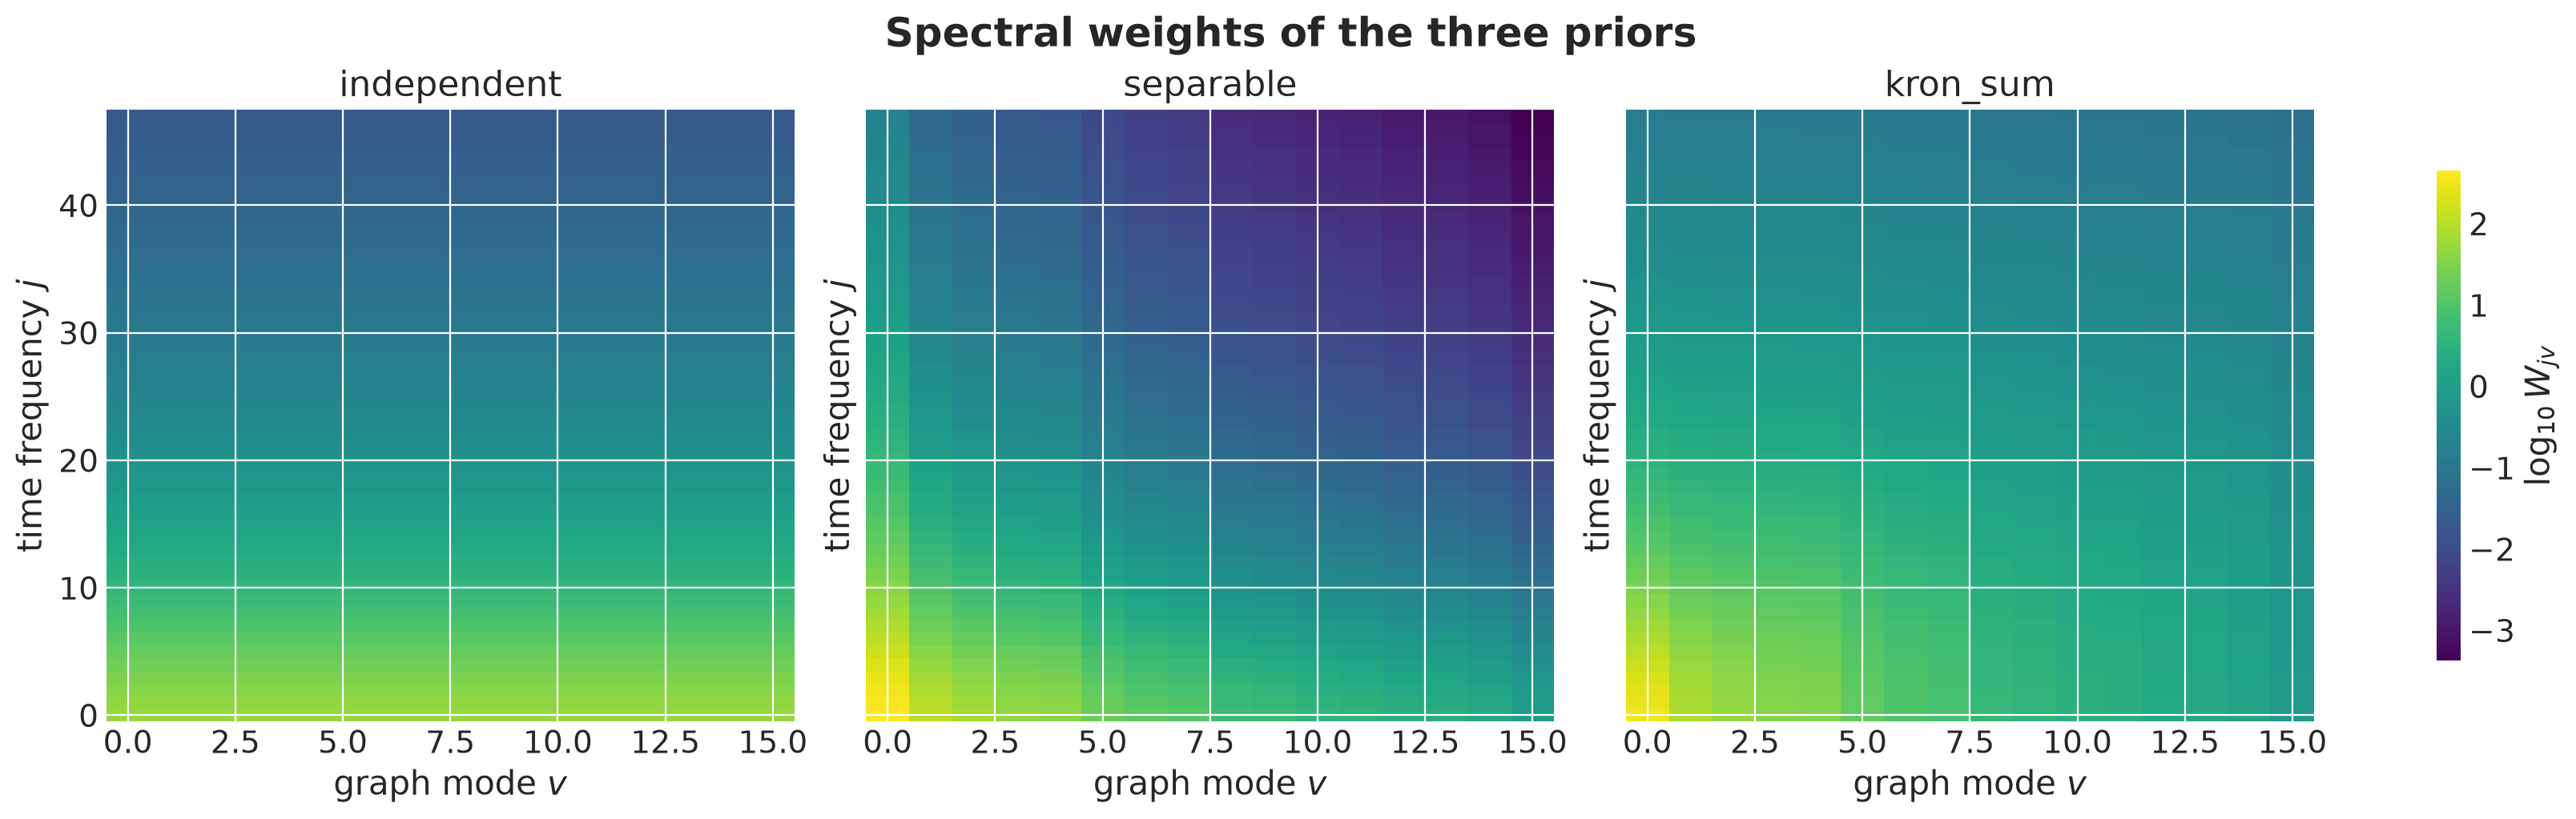

In [8]:
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(16, 5), sharey=True, layout="constrained"
)
log_w = {mode: np.log10(np.asarray(w)) for mode, w in weights_fixed.items()}
vmin = min(w.min() for w in log_w.values())
vmax = max(w.max() for w in log_w.values())
for ax, mode in zip(axes, MODES, strict=True):
    im = ax.imshow(
        log_w[mode], aspect="auto", origin="lower", cmap="viridis", vmin=vmin, vmax=vmax
    )
    ax.set(title=mode, xlabel="graph mode $v$", ylabel="time frequency $j$")
fig.colorbar(im, ax=axes, label="$\\log_{10} W_{jv}$", shrink=0.8)
fig.suptitle("Spectral weights of the three priors", fontsize=18, fontweight="bold");

### Effective Lengthscales

Under the Kronecker sum each graph mode is a temporal Matérn process with its own lengthscale $\ell_v = \ell / \sqrt{1 + \rho \mu_v}$. With $\ell = 20$ and $\rho = 2$ the roughest mode on this graph has a lengthscale of about four weeks. The basis size rule must use this value.

In [9]:
ell_modes = np.asarray(
    effective_lengthscales(mu_j, prior_hyper["length"], prior_hyper["rho"])
)
m_rule = 1.75 * C_BOX * (DURATION / 2) / ell_modes.min()

pl.DataFrame({"mu": mu.round(2), "ell_v (weeks)": ell_modes.round(1)}).transpose(
    include_header=True, header_name="quantity", column_names=mode_names
)

quantity,mode 0,mode 1,mode 2,mode 3,mode 4,mode 5,mode 6,mode 7,mode 8,mode 9,mode 10,mode 11,mode 12,mode 13,mode 14,mode 15
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""mu""",0.0,0.51,0.79,1.02,1.11,1.84,2.39,2.71,3.89,4.21,4.86,5.12,5.93,6.19,7.25,10.19
"""ell_v (weeks)""",20.0,14.0,12.5,11.5,11.2,9.2,8.3,7.9,6.7,6.5,6.1,6.0,5.6,5.5,5.1,4.3


In [10]:
print(f"shortest effective lengthscale: {ell_modes.min():.1f} weeks")
print(f"basis size rule: m >= {m_rule:.0f} (we use m = {M_BASIS})")

shortest effective lengthscale: 4.3 weeks
basis size rule: m >= 51 (we use m = 48)


The rule asks for more basis functions than we use. We keep $m = 48$ for speed and come back to this point after the fit, where we check the rule against the posterior and refit with a larger $m$.

### Non-Separability

What does non-separable mean in practice? For a separable kernel $k((t, r), (t', r')) = k_t(t - t')\, k_G(r, r')$, the spatial correlation pattern is the same at every time lag: the ratio of the correlation between adjacent regions to the correlation between non-adjacent regions does not depend on the lag. For the Kronecker sum, rough spatial modes decay faster in time, so at long lags only the smooth national mode survives and all regions become equally correlated. We compute the approximate kernel from the basis and check this directly. We standardize the nodes first so that all regions have the same variance.

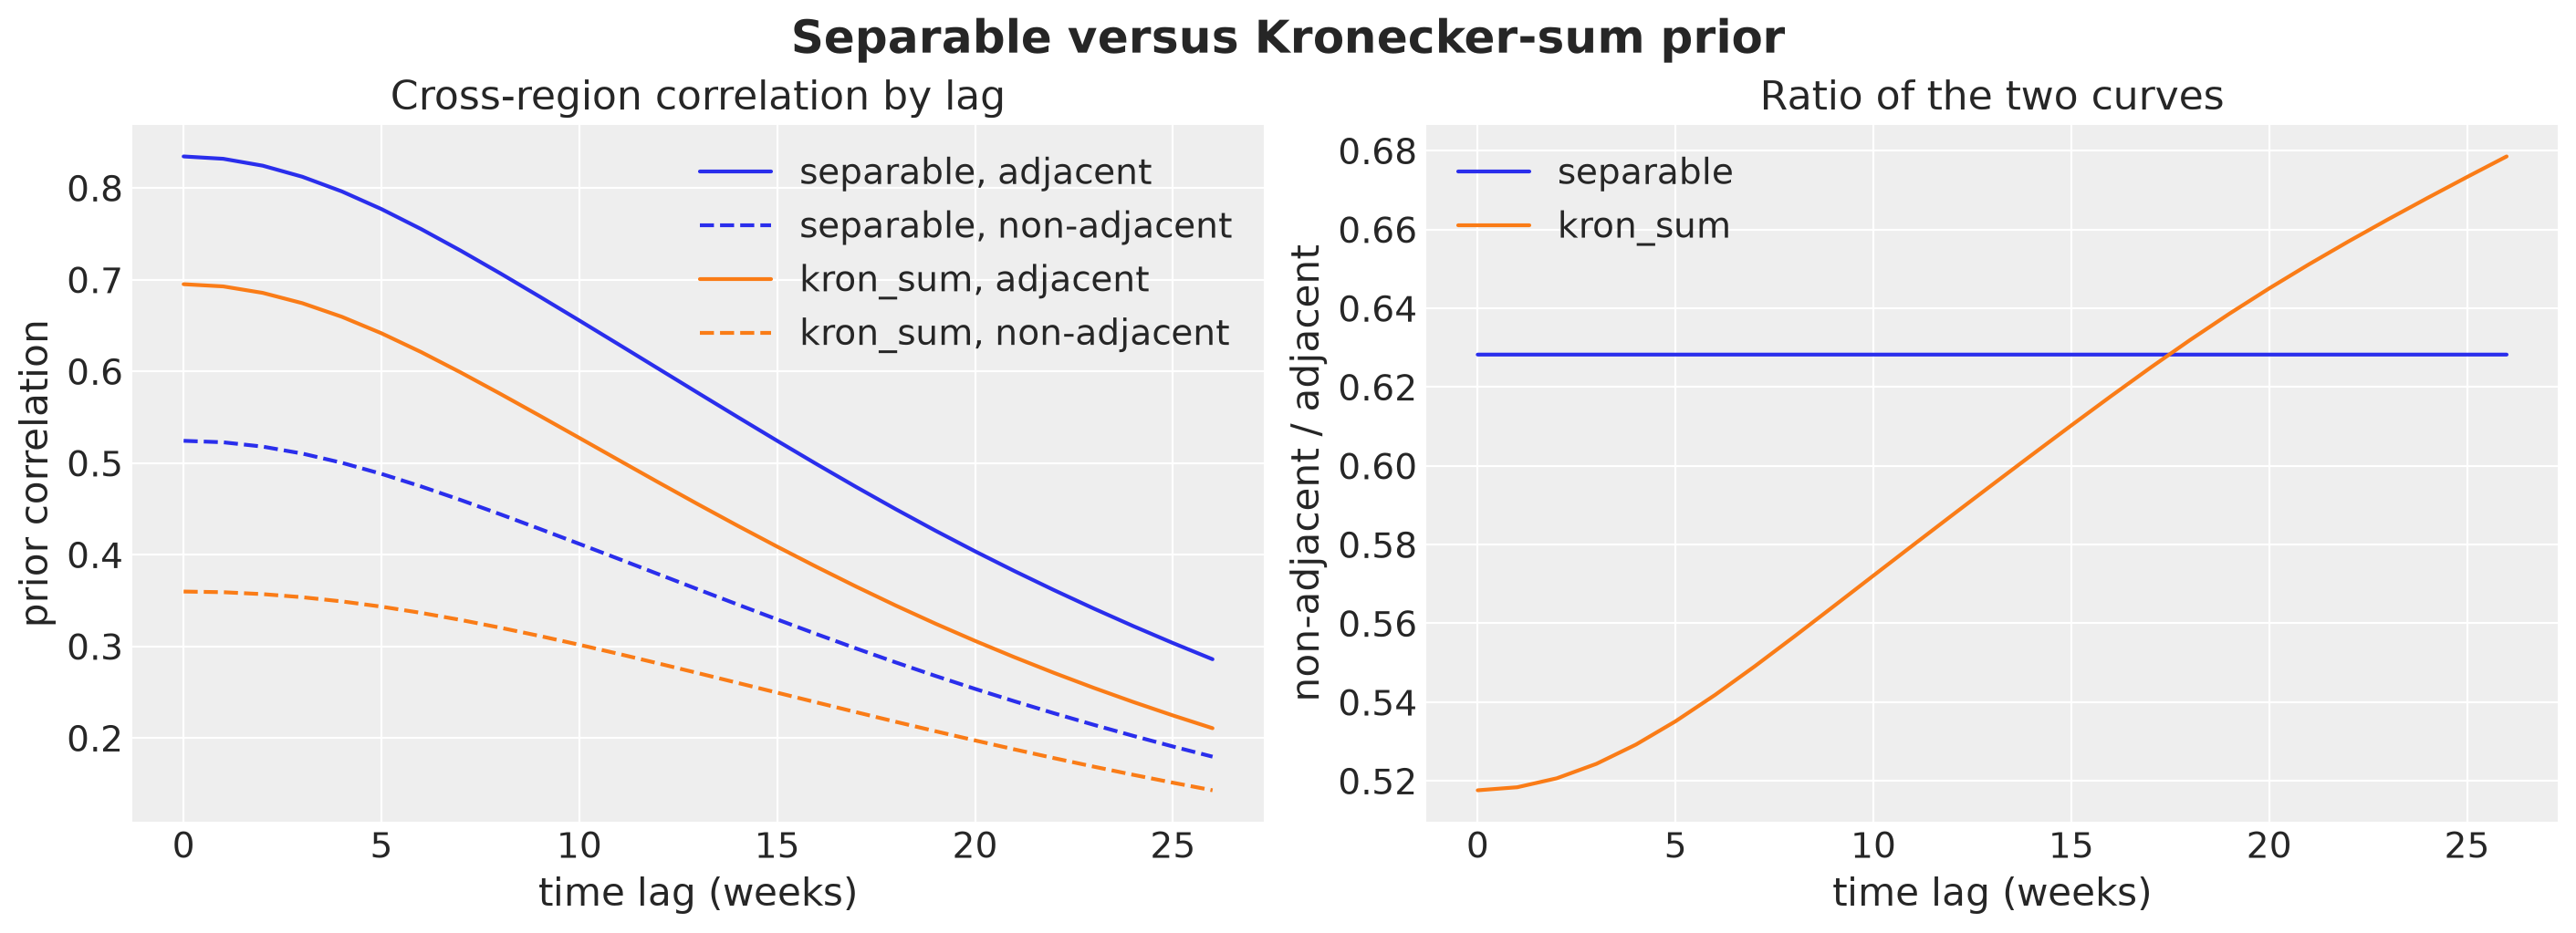

In [11]:
def standardized_U(
    weights: Float[Array, "m R"],
    U: Float[Array, "R R"],
    ell_box: float,
    sigma_f: Float[Array, ""],
) -> np.ndarray:
    "Eigenvector matrix D U with the node standardization folded in."
    scale = sigma_f / jnp.sqrt(node_variances(weights, U, ell_box))
    return np.asarray(U * scale[:, None])


adjacent = adjacency.astype(bool)
non_adjacent = ~adjacent & ~np.eye(R, dtype=bool)

lags = np.arange(0, 27)
t0 = DURATION // 2
phi_np = np.asarray(phi_full)

corr_by_lag = {}
for mode in ["separable", "kron_sum"]:
    U_mode = standardized_U(weights_fixed[mode], U_j, ell_box, prior_hyper["sigma_f"])
    kernel = approximate_kernel(
        phi_np, U_mode, np.asarray(weights_fixed[mode])
    )  # (T, R, T, R)
    sd = np.sqrt(np.einsum("trtr->tr", kernel))
    corr = kernel / (sd[:, :, None, None] * sd[None, None, :, :])
    corr_by_lag[mode] = {
        "adjacent": np.array([corr[t0, :, t0 + k, :][adjacent].mean() for k in lags]),
        "non-adjacent": np.array(
            [corr[t0, :, t0 + k, :][non_adjacent].mean() for k in lags]
        ),
    }

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for i, mode in enumerate(["separable", "kron_sum"]):
    for j, pair in enumerate(["adjacent", "non-adjacent"]):
        axes[0].plot(
            lags,
            corr_by_lag[mode][pair],
            color=f"C{i}",
            linestyle=["-", "--"][j],
            label=f"{mode}, {pair}",
        )
    ratio = corr_by_lag[mode]["non-adjacent"] / corr_by_lag[mode]["adjacent"]
    axes[1].plot(lags, ratio, color=f"C{i}", label=mode)
axes[0].set(
    xlabel="time lag (weeks)",
    ylabel="prior correlation",
    title="Cross-region correlation by lag",
)
axes[0].legend()
axes[1].set(
    xlabel="time lag (weeks)",
    ylabel="non-adjacent / adjacent",
    title="Ratio of the two curves",
)
axes[1].legend()
fig.suptitle("Separable versus Kronecker-sum prior", fontsize=18, fontweight="bold");

For the separable prior the ratio is flat: the spatial pattern of the correlations is the same at every lag. For the Kronecker sum the ratio increases with the lag: far apart in time, all regions look alike because only the national mode has memory that long. This is the behavior we want for a forecast: as the horizon grows, the regional forecasts revert toward the national one.

### Node Standardization

The graph Matérn prior does not have the same variance at every node. We compute $v_r$ for the Kronecker-sum prior before and after the standardization.

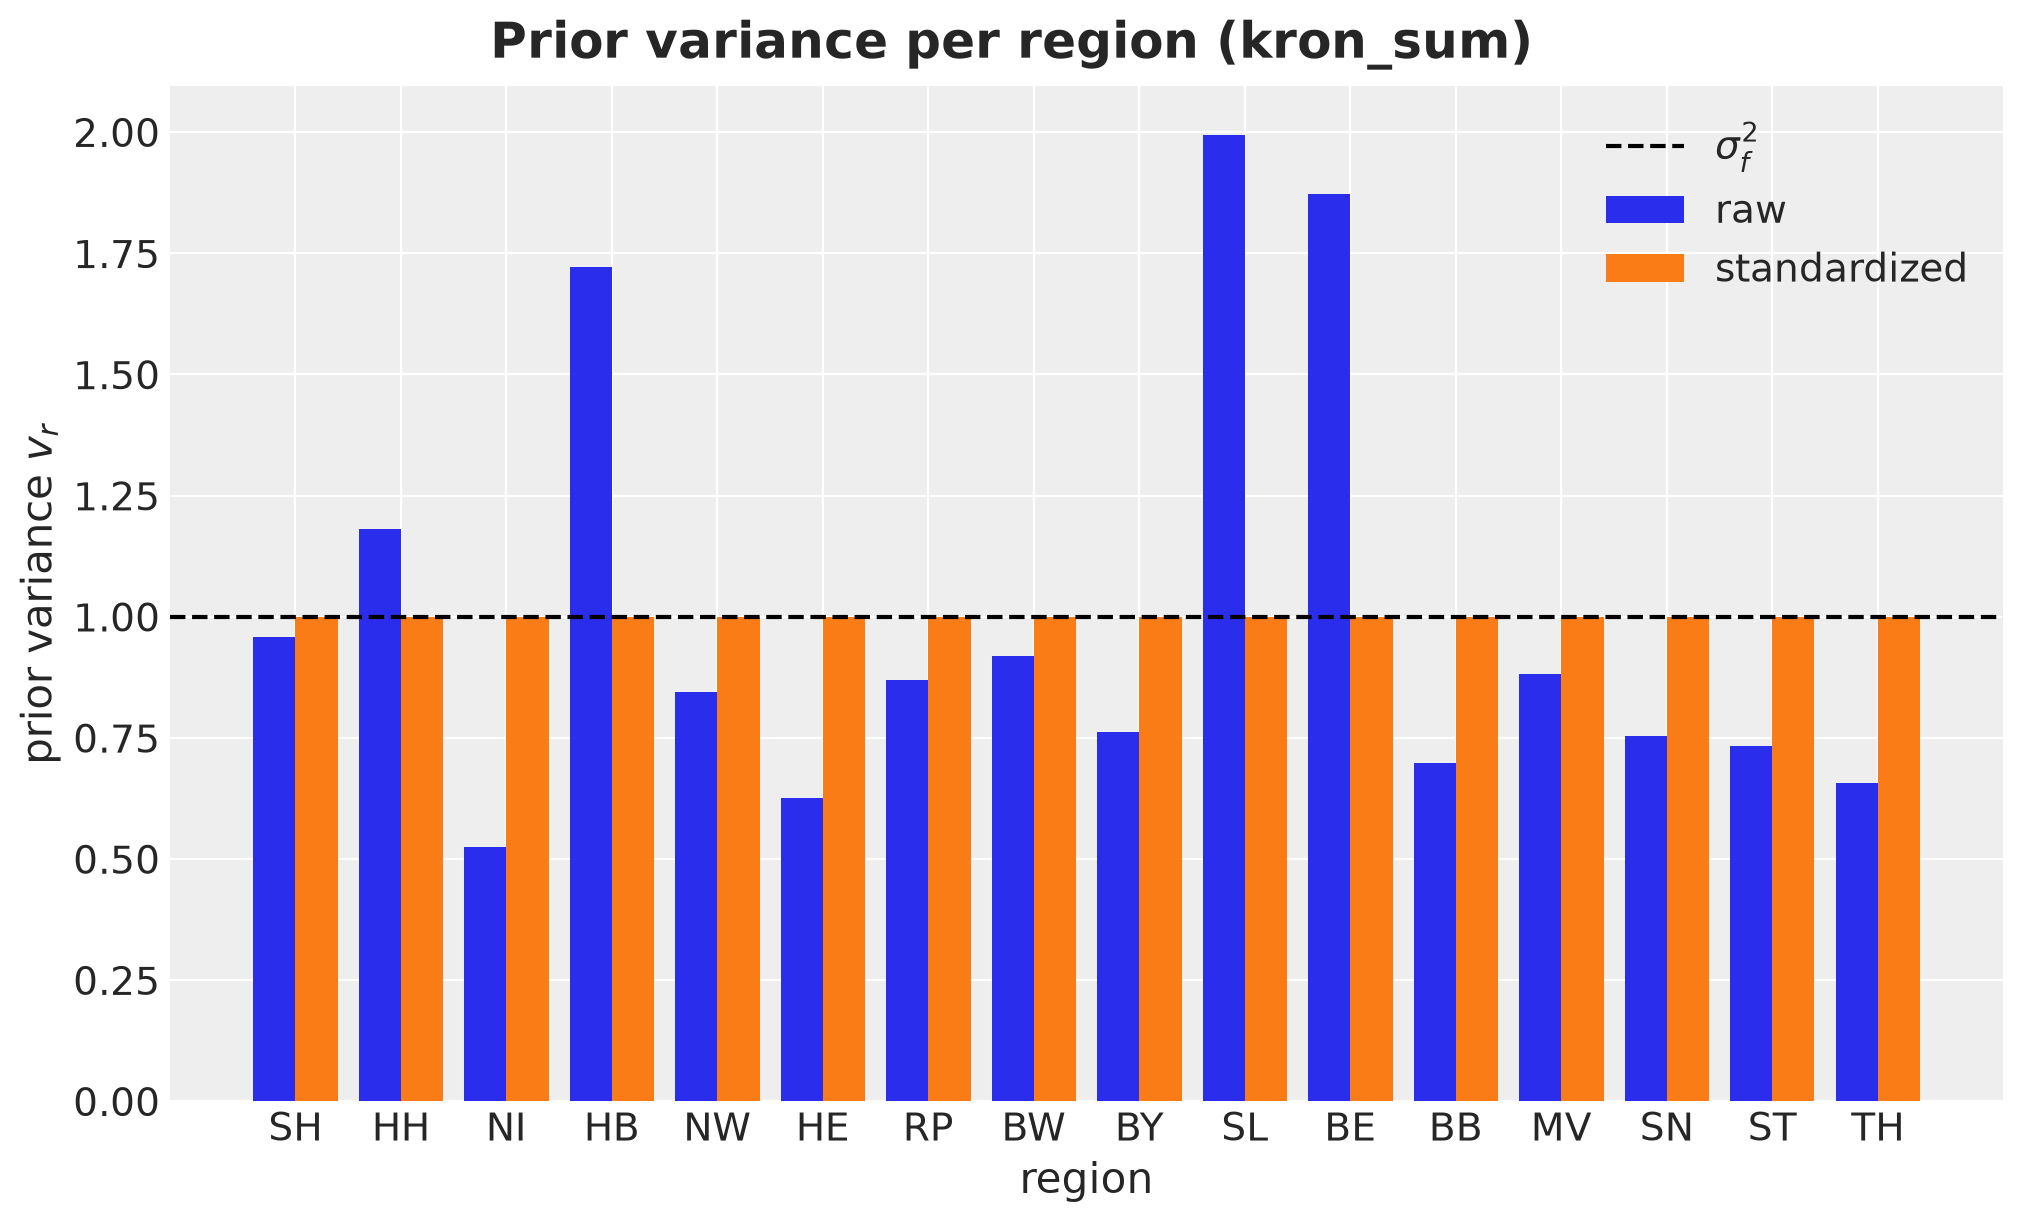

In [12]:
v_raw = np.asarray(node_variances(weights_fixed["kron_sum"], U_j, ell_box))
U_std = standardized_U(weights_fixed["kron_sum"], U_j, ell_box, prior_hyper["sigma_f"])
v_std = np.asarray(
    node_variances(weights_fixed["kron_sum"], jnp.asarray(U_std), ell_box)
)

fig, ax = plt.subplots()
x = np.arange(R)
ax.bar(x - 0.2, v_raw, width=0.4, color="C0", label="raw")
ax.bar(x + 0.2, v_std, width=0.4, color="C1", label="standardized")
ax.axhline(
    y=float(prior_hyper["sigma_f"]) ** 2,
    color="black",
    linestyle="--",
    label="$\\sigma_f^2$",
)
ax.set(xticks=x, xticklabels=STATES, ylabel="prior variance $v_r$", xlabel="region")
ax.legend()
fig.suptitle("Prior variance per region (kron_sum)", fontsize=18, fontweight="bold");

In [13]:
ratio = v_raw.max() / v_raw.min()
print(f"raw variance range: [{v_raw.min():.2f}, {v_raw.max():.2f}] (ratio {ratio:.1f})")
print(f"standardized range: [{v_std.min():.2f}, {v_std.max():.2f}]")

raw variance range: [0.53, 1.99] (ratio 3.8)
standardized range: [1.00, 1.00]


The raw prior gives the low-degree states (Bremen, Saarland, Berlin) a much wider prior band than the hubs. After the standardization every region has variance $\sigma_f^2$ and the graph only shapes the correlations.

### Prior Draws

Finally we draw one latent panel from each prior with the *same* coefficients $\beta_{jv}$. Only the weights differ, so the three panels are directly comparable. We write a small helper that samples $f$ for a given mode; the forecasting models below reuse the same building blocks.

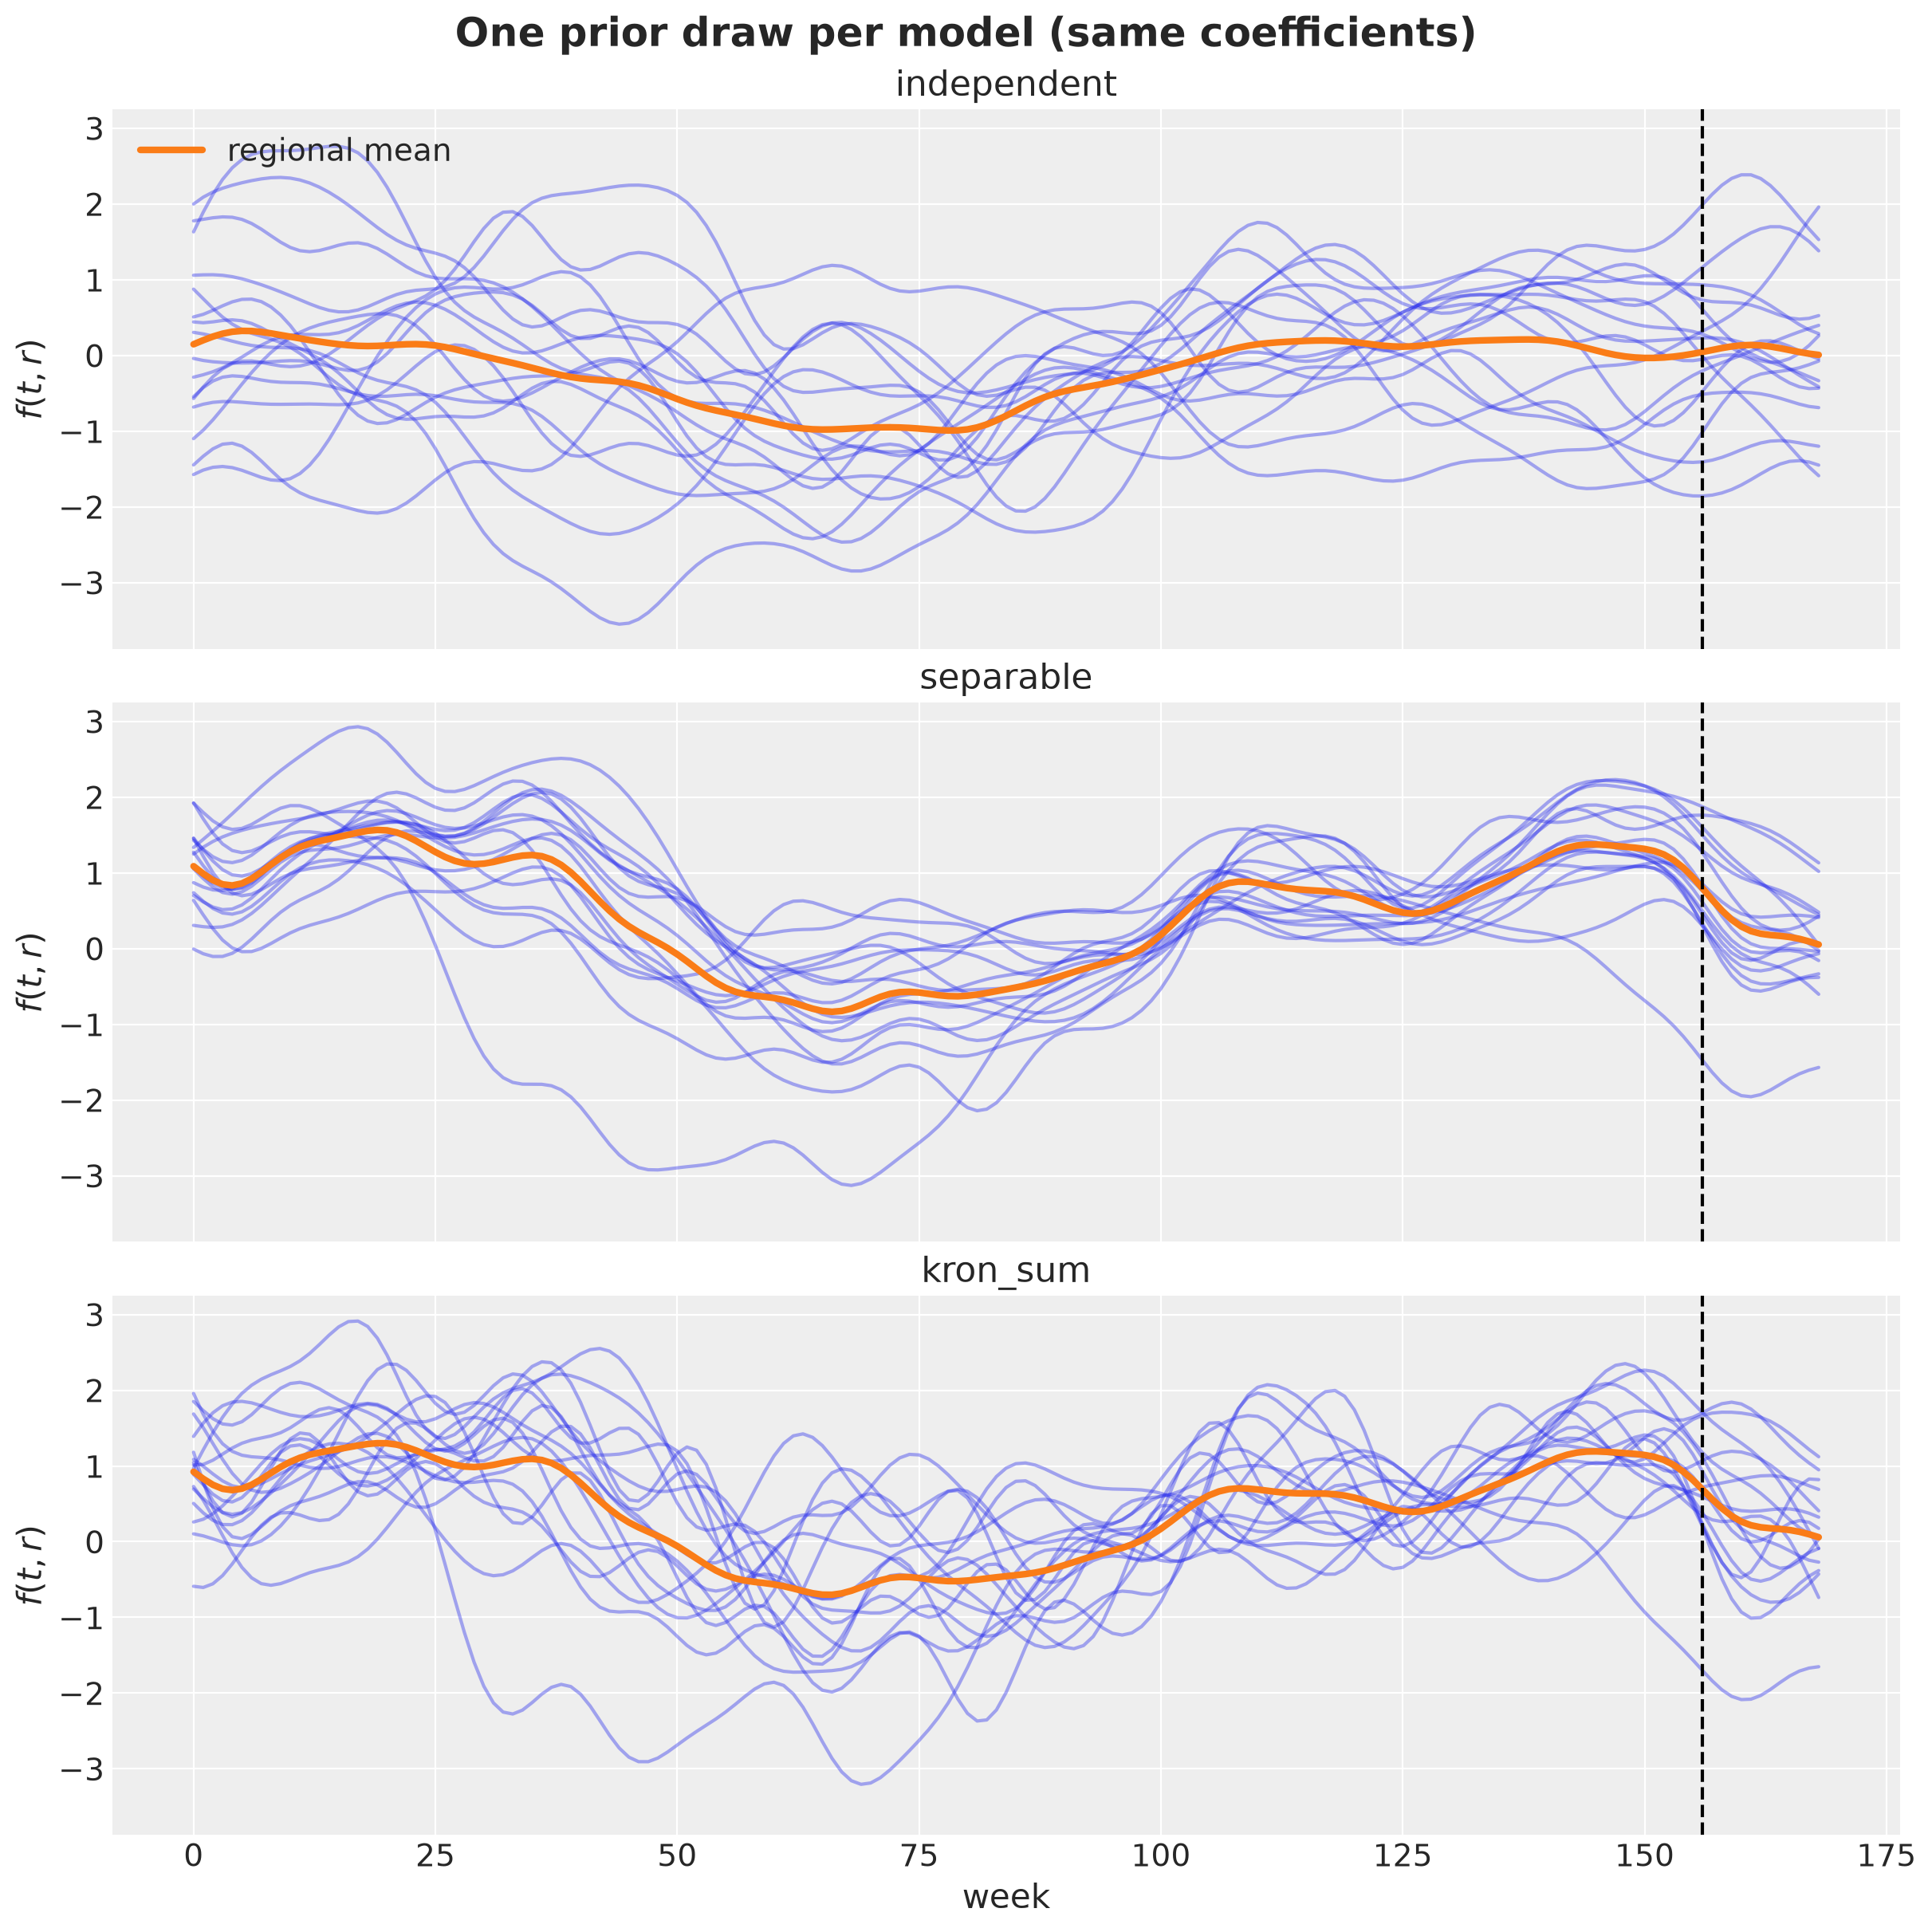

In [14]:
def latent_prior(mode: Mode, m: int = M_BASIS, nu: float = NU):
    "Prior on the latent panel f with the three hyperparameters as sample sites."
    phi_m = phi_full if m == M_BASIS else time_basis(t_c, ell_box, m)[0]
    lam_m = lam if m == M_BASIS else time_basis(t_c, ell_box, m)[1]

    def model():
        sigma_f = numpyro.sample("sigma_f", dist.HalfNormal(1.0))
        length = numpyro.sample("length", dist.LogNormal(jnp.log(20.0), 0.7))
        rho = numpyro.sample("rho", dist.LogNormal(0.0, 1.5))
        w = spectral_weights(
            lam_m,
            mu_j,
            mode=mode,
            nu=nu,
            length=length,
            rho=rho,
            sigma_f=sigma_f,
            ell_box=ell_box,
        )
        scale = (
            None
            if mode == "independent"
            else sigma_f / jnp.sqrt(node_variances(w, U_j, ell_box))
        )
        kron_hsgp("gp", phi_m, U_j, w, mode=mode, scale=scale)

    return model


rng_key, rng_subkey = random.split(rng_key)
prior_draws = {
    mode: Predictive(substitute(latent_prior(mode), data=prior_hyper), num_samples=1)(
        rng_subkey
    )["gp_f"][0]
    for mode in MODES
}

fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
for ax, mode in zip(axes, MODES, strict=True):
    f_draw = np.asarray(prior_draws[mode])
    for r in range(R):
        ax.plot(f_draw[:, r], color="C0", alpha=0.4)
    ax.plot(f_draw.mean(axis=1), color="C1", linewidth=3, label="regional mean")
    ax.axvline(x=T_OBS, color="black", linestyle="--")
    ax.set(title=mode, ylabel="$f(t, r)$")
axes[0].legend(loc="upper left")
axes[-1].set(xlabel="week")
fig.suptitle(
    "One prior draw per model (same coefficients)", fontsize=18, fontweight="bold"
);

The independent draw has no common structure across regions, and the regional mean is damped. The separable draw pools the regions, and every regional deviation is as smooth as the trend, because all graph modes share the lengthscale $\ell$. In the Kronecker-sum draw the regions share the same trend, but the deviations have a shorter memory: they move faster and keep reverting to the common shape. This is what a diffusion on the network looks like.

## Data Generating Process

We simulate the panel with a generative model that is deliberately different from the forecasting model, so that the comparison below is not a parameter-recovery exercise. The simulation is a NumPyro model. We fix the true parameters with the `do` handler and take one draw.

- National trend: one draw of a Matérn-$5/2$ Gaussian process in time with lengthscale $40$ weeks.
- Regional deviations: a graph Ornstein-Uhlenbeck process, $x_{t + 1} = e^{-(\theta I + a L_G)} x_t + \varepsilon_t$, a diffusion on the network. In graph-spectral coordinates this is an independent AR(1) per mode with coefficient $e^{-(\theta + a \mu_v)}$. Its stationary law is an exponential (Matérn-$1/2$) kernel in time with a mode-specific decay and a mode-specific variance. So the deviations are rougher in time ($\nu = 1/2$) than the model assumes ($\nu = 3/2$) and have a different variance profile over the graph modes. We set the constant mode to zero because the national trend already covers it.
- Seasonality: a yearly Fourier pair with fixed weights.
- Observation noise: Student-t with $6$ degrees of freedom.

In [15]:
def panel_dgp(
    mu: Float[Array, " R"],
    U: Float[Array, "R R"],
    duration: int,
    period: float = PERIOD,
) -> None:
    "Weekly panel: trend + graph OU deviations + seasonality + Student-t noise."
    R = mu.shape[0]
    t = jnp.arange(duration, dtype=jnp.float32)
    dt = jnp.abs(t[:, None] - t[None, :])
    jitter = 1e-4 * jnp.eye(duration)
    # hyperparameters (fixed with `do` below)
    trend_length = numpyro.sample("trend_length", dist.LogNormal(jnp.log(40.0), 0.5))
    trend_scale = numpyro.sample("trend_scale", dist.HalfNormal(1.0))
    theta = numpyro.sample("theta", dist.LogNormal(jnp.log(0.1), 0.5))
    diffusion = numpyro.sample("diffusion", dist.LogNormal(jnp.log(0.05), 0.5))
    dev_noise = numpyro.sample("dev_noise", dist.HalfNormal(0.5))
    w_seas = numpyro.sample("w_seas", dist.Normal(0.0, 0.5).expand([4]).to_event(1))
    obs_scale = numpyro.sample("obs_scale", dist.HalfNormal(0.5))
    obs_df = numpyro.sample("obs_df", dist.Gamma(4.0, 0.5))
    # national trend: Matern-5/2 in time
    d = dt / trend_length
    k_trend = (
        trend_scale**2
        * (1 + jnp.sqrt(5) * d + 5 * d**2 / 3)
        * jnp.exp(-jnp.sqrt(5) * d)
    )
    trend = numpyro.sample(
        "trend", dist.MultivariateNormal(jnp.zeros(duration), k_trend + jitter)
    )
    # regional deviations: stationary graph OU, one AR(1) per non-constant graph mode
    decay = jnp.exp(-(theta + diffusion * mu[1:]))  # (R - 1,)
    variance = dev_noise**2 / (1 - decay**2)
    k_dev = variance[:, None, None] * decay[:, None, None] ** dt[None]  # (R - 1, T, T)
    z = numpyro.sample(
        "z", dist.MultivariateNormal(jnp.zeros(duration), k_dev + jitter)
    )  # (R - 1, T)
    dev = numpyro.deterministic("dev", z.T @ U[:, 1:].T)  # (T, R)
    # intercept, seasonality, and observation noise
    intercept = numpyro.sample(
        "intercept", dist.Normal(0.0, 0.5).expand([R]).to_event(1)
    )
    seasonal = fourier_features(duration, period=period, num_terms=2) @ w_seas
    latent = numpyro.deterministic(
        "latent", intercept + trend[:, None] + seasonal[:, None] + dev
    )
    numpyro.sample("y", dist.StudentT(obs_df, latent, obs_scale).to_event(2))


true_values = {
    "trend_length": 40.0,
    "trend_scale": 1.0,
    "theta": 0.08,
    "diffusion": 0.05,
    "dev_noise": 0.35,
    "w_seas": jnp.array([0.6, 0.0, 0.0, 0.25]),
    "obs_scale": 0.25,
    "obs_df": 6.0,
}

rng_key, rng_subkey = random.split(rng_key)
simulation = Predictive(do(panel_dgp, data=true_values), num_samples=1)(
    rng_subkey, mu_j, U_j, DURATION
)

y = simulation["y"][0]  # (DURATION, R)
latent_true = simulation["latent"][0]
trend_true = simulation["trend"][0]
dev_true = simulation["dev"][0]

print(f"panel shape (weeks, regions) = {y.shape}")

panel shape (weeks, regions) = (169, 16)


The graph OU process makes the deviations spatially smooth: the smooth graph modes have the longest memory and the largest variance. We look at the components of the simulation.

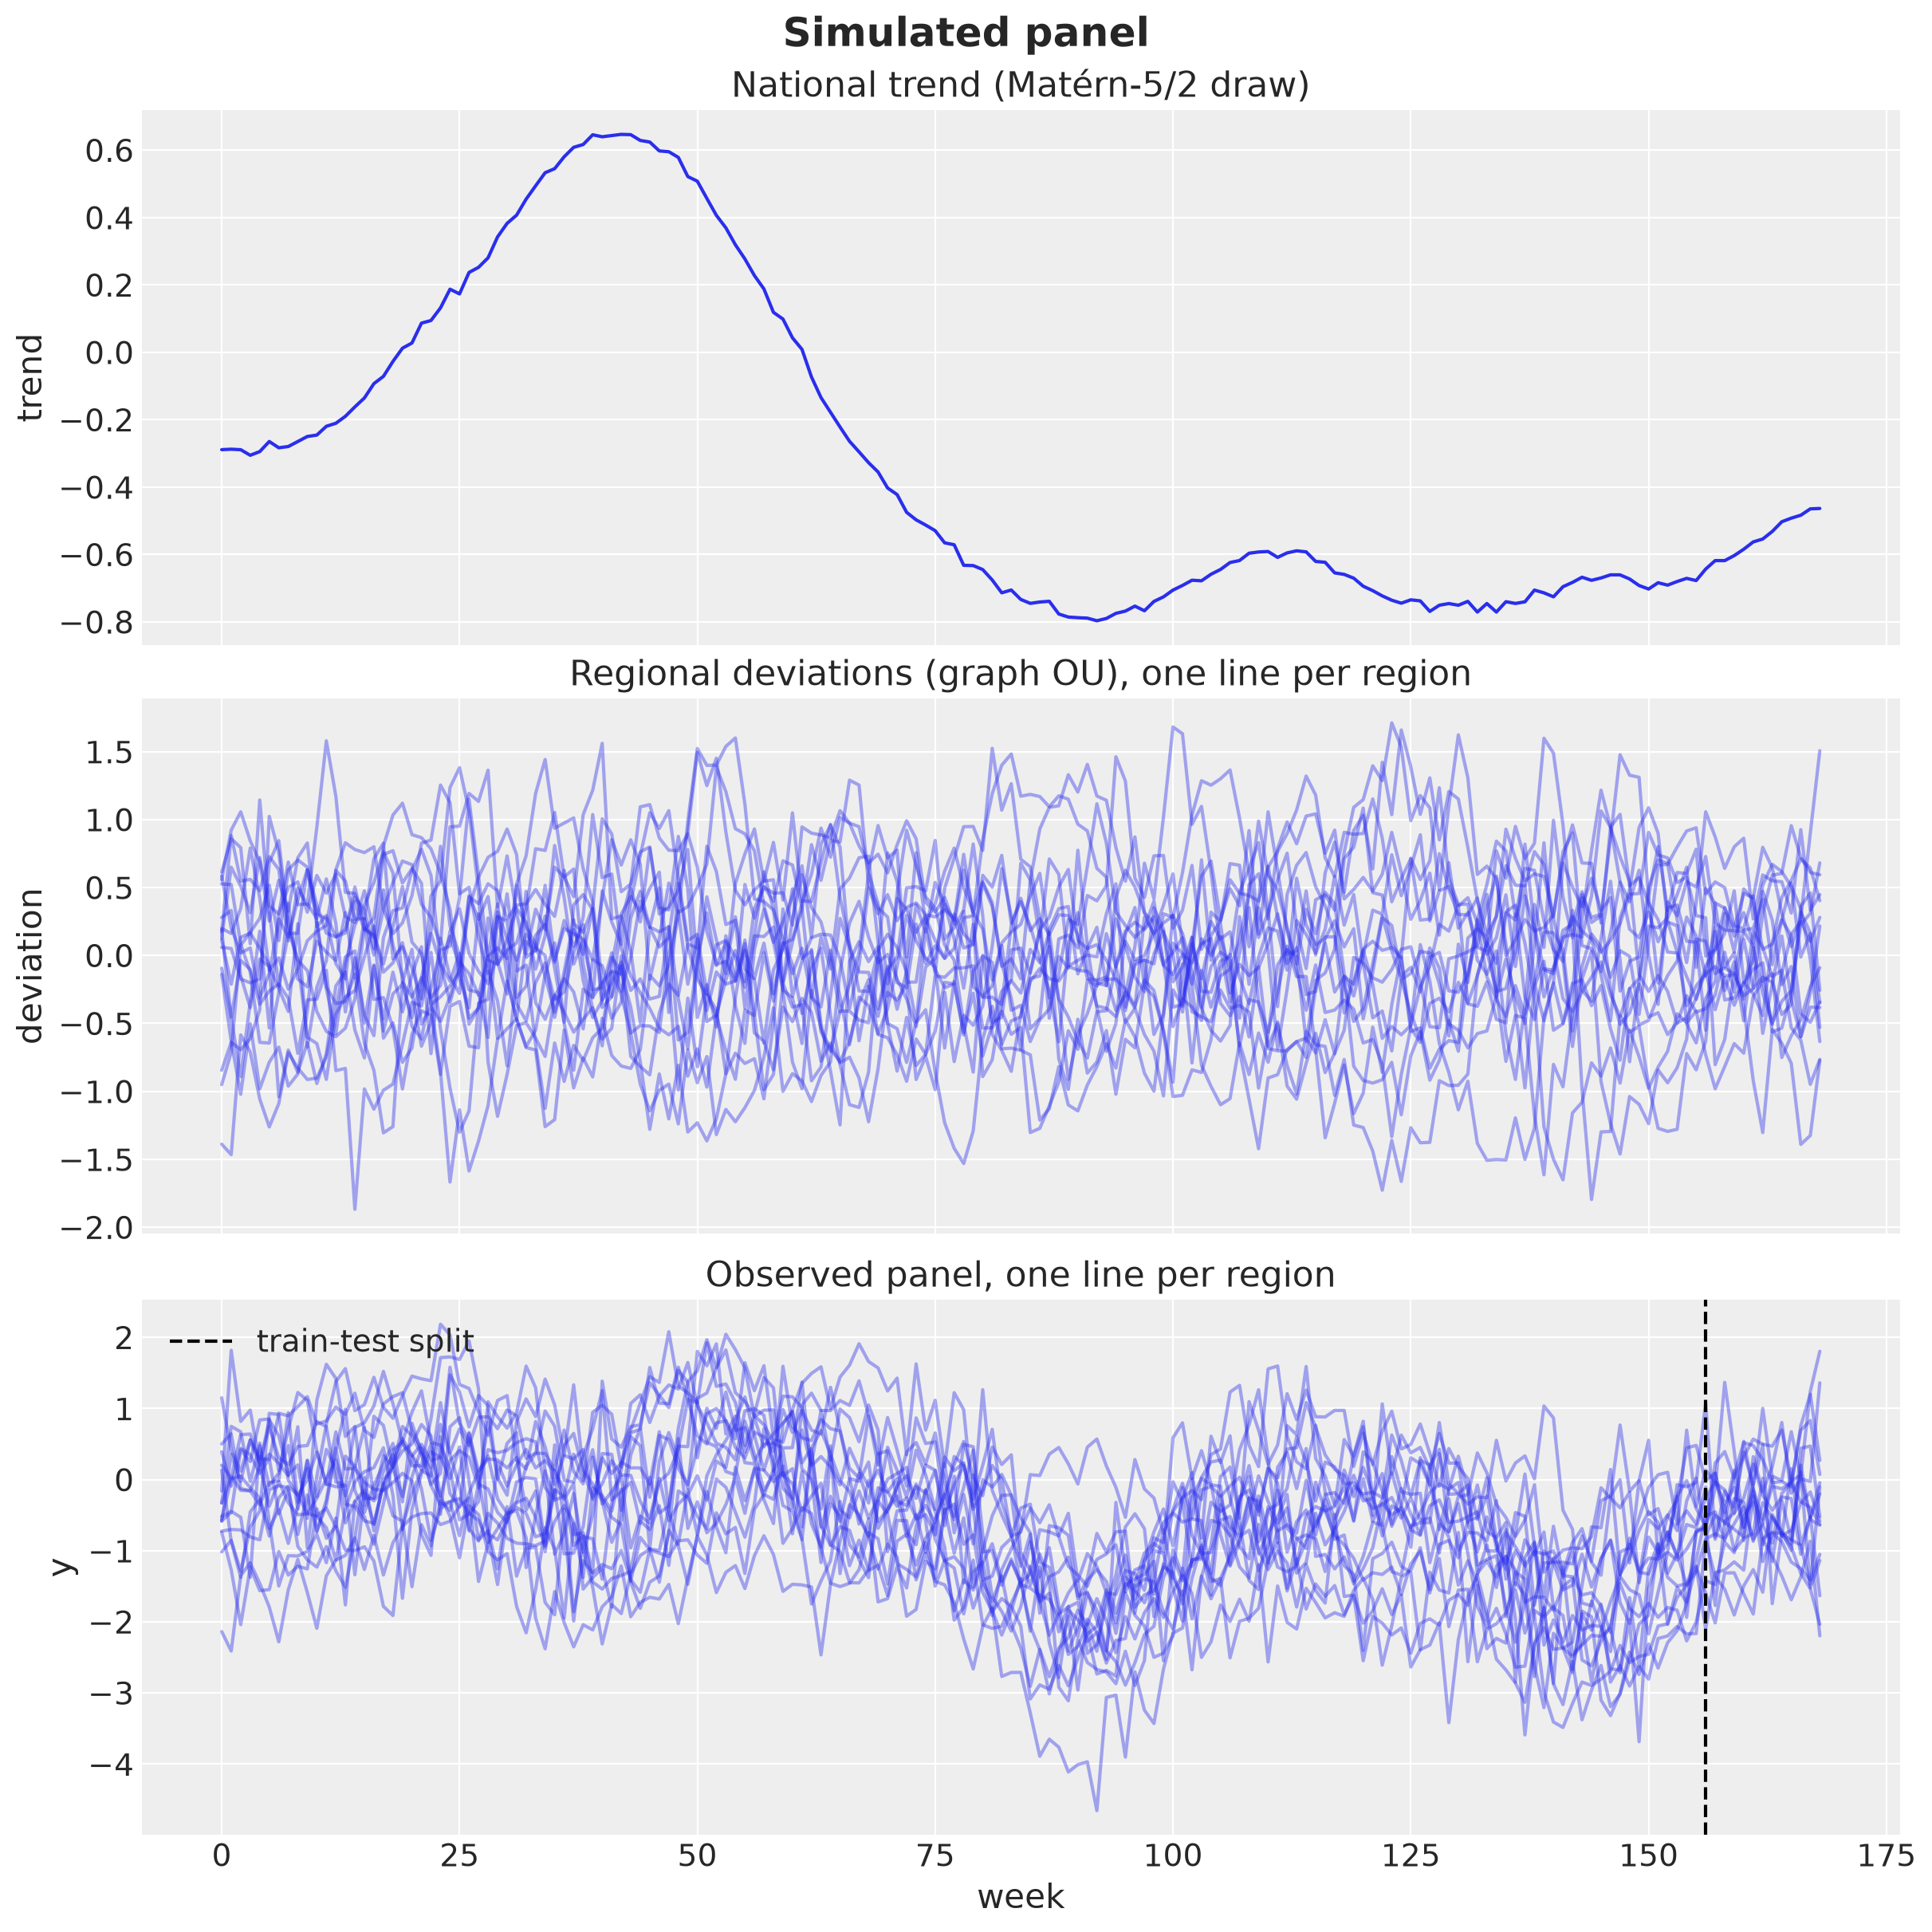

In [16]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, layout="constrained"
)
axes[0].plot(np.asarray(trend_true), color="C0")
axes[0].set(title="National trend (Matérn-5/2 draw)", ylabel="trend")
for r in range(R):
    axes[1].plot(np.asarray(dev_true[:, r]), color="C0", alpha=0.4)
axes[1].set(
    title="Regional deviations (graph OU), one line per region", ylabel="deviation"
)
for r in range(R):
    axes[2].plot(np.asarray(y[:, r]), color="C0", alpha=0.4)
axes[2].axvline(x=T_OBS, color="black", linestyle="--", label="train-test split")
axes[2].set(title="Observed panel, one line per region", ylabel="y", xlabel="week")
axes[2].legend(loc="upper left")
fig.suptitle("Simulated panel", fontsize=18, fontweight="bold");

## Train-Test Split

We keep the first $T = 156$ weeks for training and the last $H = 13$ weeks as the test set. The covariates are the Fourier features of the yearly seasonality over the full duration. Following the `numpyro-forecast` convention, time is at axis $-2$ and the regions at axis $-1$.

In [17]:
covariates = fourier_features(DURATION, period=PERIOD, num_terms=2)  # (DURATION, 4)
covariates_train = covariates[:T_OBS]

y_train = y[:T_OBS]
y_test = y[T_OBS:]

print(f"train {y_train.shape}, test {y_test.shape}, covariates {covariates.shape}")

train (156, 16), test (13, 16), covariates (169, 4)


## The Forecasting Models

One model factory produces the three models. The model follows the `numpyro-forecast` convention: it takes `(covariates, data)`, derives the train and forecast split with `Horizon.from_data`, builds the prediction over the full covariate duration, and hands it to `predict`, which observes the in-sample prefix and samples the forecast suffix.

Two details matter.

- **The time box is fixed once.** The basis must be the same at training time and at forecast time. If we built the box from the length of the current call, the training call (156 weeks) and the forecast call (169 weeks) would use different boxes, and the posterior coefficients would be read against the wrong basis. So the factory takes the full `duration`, builds the basis once, and each call slices the prefix it needs.
- **The node standardization is folded into $U$.** We multiply the rows of $U$ by the scales $s_r$ before the second matrix multiplication (this is the $D U$ of the $D K D$ kernel), so the GP block stays two matrix multiplications.

The priors are weakly informative: $\sigma_f \sim \text{HalfNormal}(1)$, $\ell \sim \text{LogNormal}(\log 20, 0.7)$, $\rho \sim \text{LogNormal}(0, 1.5)$ (absent in the independent model), regional intercepts $a_r \sim \text{Normal}(0, 1)$, seasonal weights $\text{Normal}(0, 0.5)$, $\sigma \sim \text{HalfNormal}(0.5)$, and $\nu_{\varepsilon} \sim \text{Gamma}(4, 0.5)$.

In [18]:
def make_model(
    mu: Float[Array, " R"],
    U: Float[Array, "R R"],
    *,
    mode: Mode,
    duration: int,
    m: int = M_BASIS,
    c: float = C_BOX,
    nu: float = NU,
):
    "Forecasting model factory. The time box covers `duration` steps and is fixed."
    R = mu.shape[0]
    t_c, ell_box = time_box(duration, c=c)
    phi_full, lam = time_basis(t_c, ell_box, m)

    def model(
        covariates: Float[Array, "duration K"], data: Float[Array, "T R"] | None = None
    ) -> None:
        h = Horizon.from_data(covariates, data)
        phi = phi_full[: h.duration]  # prefix of the fixed basis
        # gp hyperparameters
        sigma_f = numpyro.sample("sigma_f", dist.HalfNormal(1.0))
        length = numpyro.sample("length", dist.LogNormal(jnp.log(20.0), 0.7))
        rho = (
            numpyro.sample("rho", dist.LogNormal(0.0, 1.5))
            if mode != "independent"
            else jnp.zeros(())
        )
        # latent panel
        w = spectral_weights(
            lam,
            mu,
            mode=mode,
            nu=nu,
            length=length,
            rho=rho,
            sigma_f=sigma_f,
            ell_box=ell_box,
        )
        scale = (
            None
            if mode == "independent"
            else sigma_f / jnp.sqrt(node_variances(w, U, ell_box))
        )
        f = kron_hsgp("gp", phi, U, w, mode=mode, scale=scale)  # (duration, R)
        # intercepts and seasonality
        intercept = numpyro.sample(
            "intercept", dist.Normal(0.0, 1.0).expand([R]).to_event(1)
        )
        w_seas = numpyro.sample(
            "w_seas", dist.Normal(0.0, 0.5).expand([covariates.shape[-1]]).to_event(1)
        )
        prediction = intercept + f + (covariates @ w_seas)[:, None]
        # likelihood
        sigma = numpyro.sample("sigma", dist.HalfNormal(0.5))
        df = numpyro.sample("df", dist.Gamma(4.0, 0.5))
        predict(h, dist.StudentT(df, 0.0, sigma), prediction)

    return model


models = {mode: make_model(mu_j, U_j, mode=mode, duration=DURATION) for mode in MODES}

### Prior Predictive Check

We draw from the prior predictive of the Kronecker-sum model over the training window to check that the implied scale of the observations is reasonable.

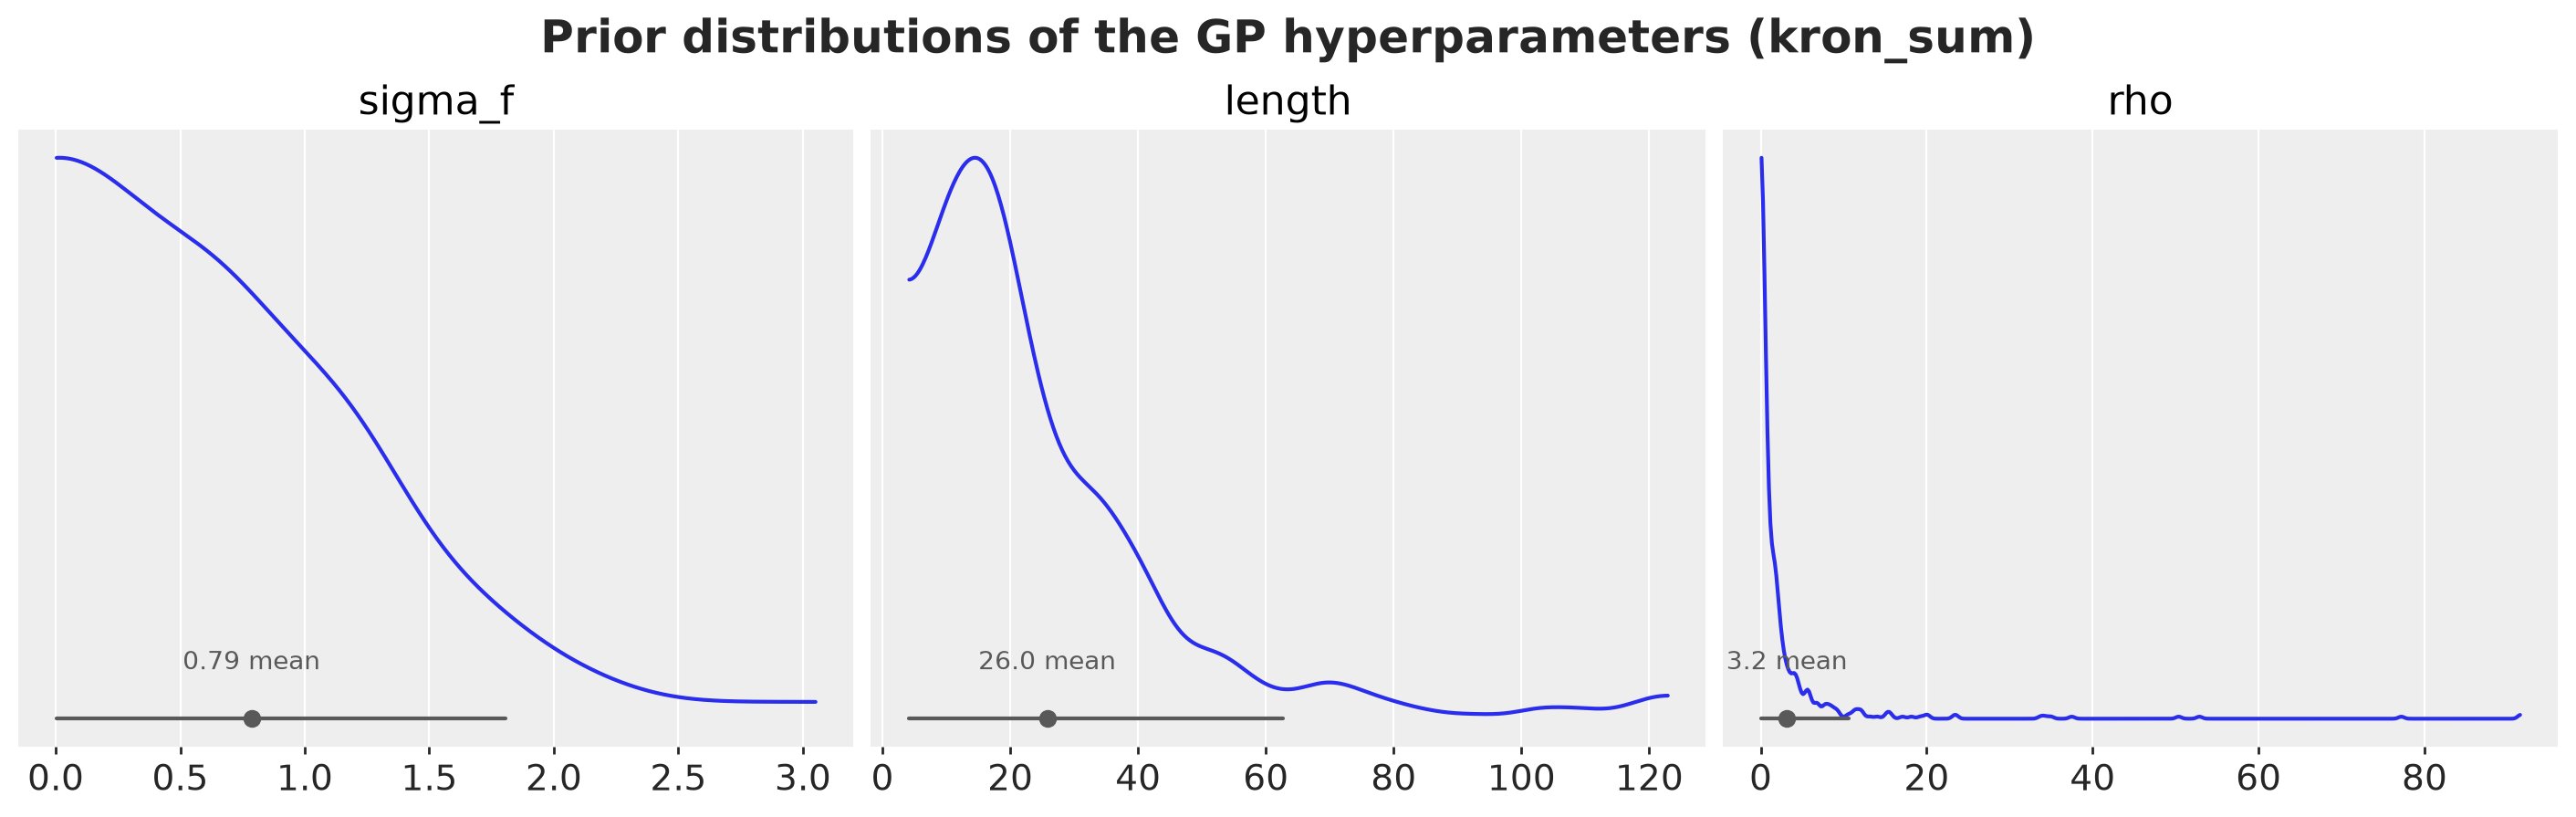

In [19]:
rng_key, rng_subkey = random.split(rng_key)
prior_predictive = Predictive(models["kron_sum"], num_samples=500)(
    rng_subkey, covariates_train
)

prior_idata = az.from_dict(
    {
        "prior": {
            k: v[None]
            for k, v in prior_predictive.items()
            if k in ["sigma_f", "length", "rho", "sigma", "df"]
        }
    }
)

pc = az.plot_dist(
    prior_idata,
    group="prior",
    var_names=["sigma_f", "length", "rho"],
    figure_kwargs={"figsize": (14, 4)},
)
pc.viz["figure"].item().suptitle(
    "Prior distributions of the GP hyperparameters (kron_sum)",
    fontsize=18,
    fontweight="bold",
    y=1.08,
);

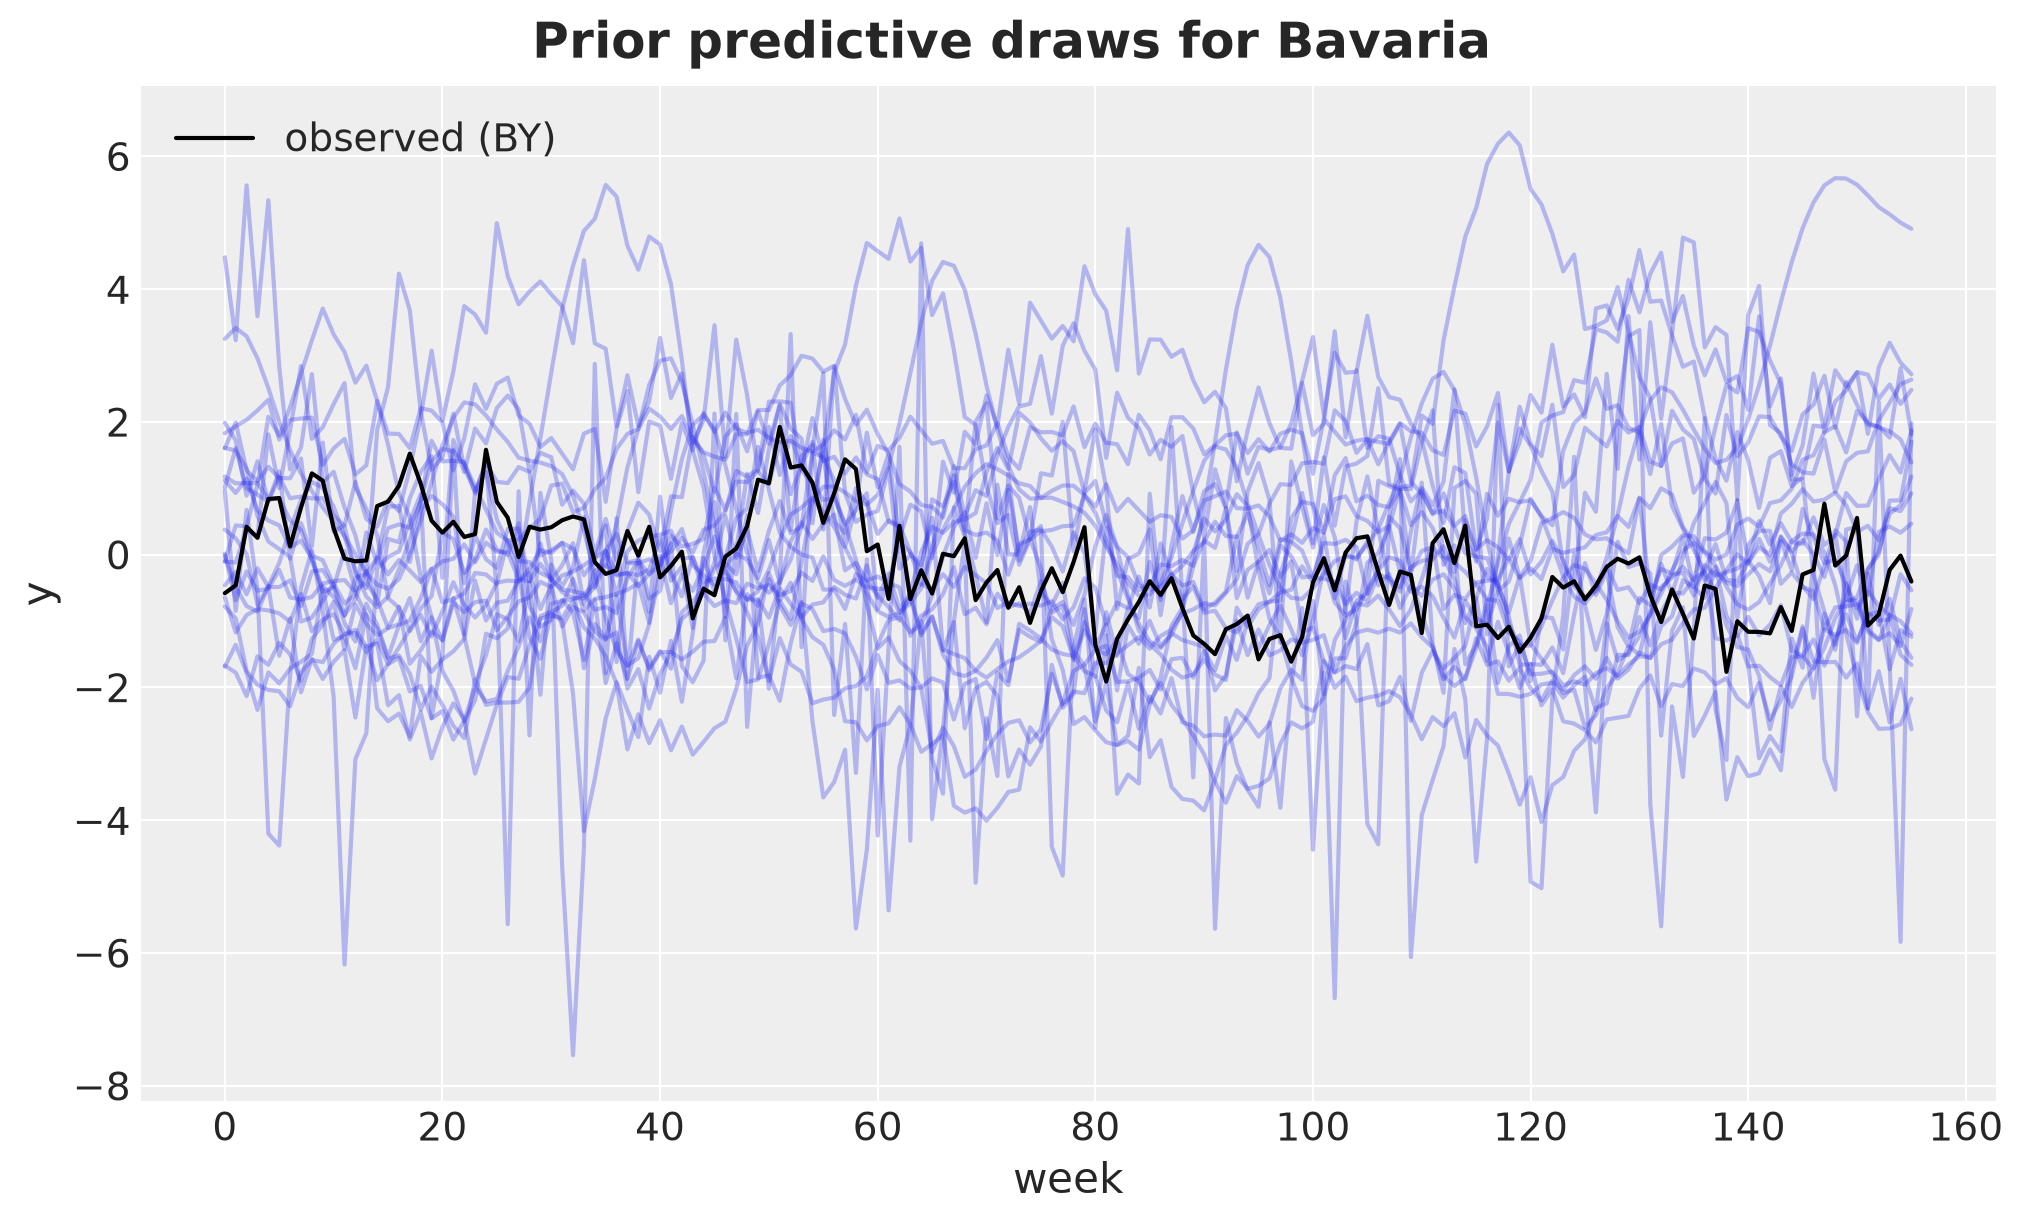

In [20]:
prior_obs = np.asarray(prior_predictive["obs"])  # (draws, T_OBS, R)

fig, ax = plt.subplots()
for i in range(20):
    ax.plot(prior_obs[i, :, state_index["BY"]], color="C0", alpha=0.3)
ax.plot(np.asarray(y_train[:, state_index["BY"]]), color="black", label="observed (BY)")
ax.legend(loc="upper left")
ax.set(xlabel="week", ylabel="y")
fig.suptitle("Prior predictive draws for Bavaria", fontsize=18, fontweight="bold");

## Model Fit and Diagnostics

We fit the three models with NUTS (4 chains, 1000 warmup and 1000 posterior draws each). Everything in the model is Gaussian conditional on a handful of hyperparameters, so the posterior is well behaved.

In [21]:
def fit_nuts(
    rng_key,
    model,
    covariates,
    data,
    *,
    num_warmup: int = 1_000,
    num_samples: int = 1_000,
    num_chains: int = 4,
) -> MCMC:
    mcmc = MCMC(
        NUTS(model, init_strategy=init_to_median, target_accept_prob=0.9),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        progress_bar=False,
    )
    mcmc.run(rng_key, covariates, data)
    return mcmc


mcmcs: dict[str, MCMC] = {}
idatas: dict[str, az.InferenceData] = {}
for mode in MODES:
    rng_key, rng_subkey = random.split(rng_key)
    t_start = time.time()
    mcmcs[mode] = fit_nuts(rng_subkey, models[mode], covariates_train, y_train)
    idatas[mode] = az.from_numpyro(mcmcs[mode])
    print(f"{mode:12s} fitted in {time.time() - t_start:.0f} s")

independent  fitted in 14 s


separable    fitted in 17 s


kron_sum     fitted in 27 s


In [22]:
for mode in MODES:
    print(f"--- {mode}")
    az.diagnose(idatas[mode])

--- independent


Divergences
No divergent transitions found.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.
--- separable


Divergences
No divergent transitions found.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.
--- kron_sum


Divergences
No divergent transitions found.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


In [23]:
hyper_names = ["sigma_f", "length", "rho", "sigma", "df"]

summaries = pl.concat(
    [
        pl.from_pandas(
            az.summary(
                idatas[mode],
                var_names=[v for v in hyper_names if v in idatas[mode]["posterior"]],
                ci_prob=HDI_PROB,
                ci_kind="hdi",
            ).reset_index(names="parameter")
        ).with_columns(pl.lit(mode).alias("model"))
        for mode in MODES
    ]
)
summaries

parameter,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,model
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""sigma_f""",0.698148,0.035915,0.635796,0.771865,1754.803864,2690.526069,1.002094,0.000858,0.000642,"""independent"""
"""length""",7.680454,0.579037,6.671162,8.834992,1554.363307,2245.287342,1.001544,0.014724,0.010268,"""independent"""
"""sigma""",0.395055,0.009966,0.376428,0.413541,4065.218899,3427.266571,1.000375,0.000156,0.000108,"""independent"""
"""df""",11.887689,2.628025,8.019451,17.779671,7005.441302,3108.410985,1.000964,0.034935,0.036028,"""independent"""
"""sigma_f""",0.642019,0.033033,0.585118,0.708302,1720.149055,2390.1088,1.000975,0.000799,0.000577,"""separable"""
…,…,…,…,…,…,…,…,…,…,…
"""sigma_f""",0.814931,0.107542,0.657391,1.056349,804.886419,1680.753513,1.003191,0.003736,0.0035,"""kron_sum"""
"""length""",13.010558,2.471438,9.145006,18.406835,693.016341,1505.406047,1.004036,0.095088,0.079946,"""kron_sum"""
"""rho""",1.998865,0.764503,0.947283,3.785152,761.533212,1608.515697,1.002812,0.027225,0.028555,"""kron_sum"""


The chains mix well: no divergences, and satisfactory effective sample sizes and $\hat{R}$ for all parameters. Note how the three models disagree on the temporal lengthscale: the independent and separable models must use a single $\ell$ for everything, and they choose a short one because the regional deviations are rough. The Kronecker-sum model assigns the short memory to the rough spatial modes through $\rho$ and keeps a longer $\ell$ for the national trend.

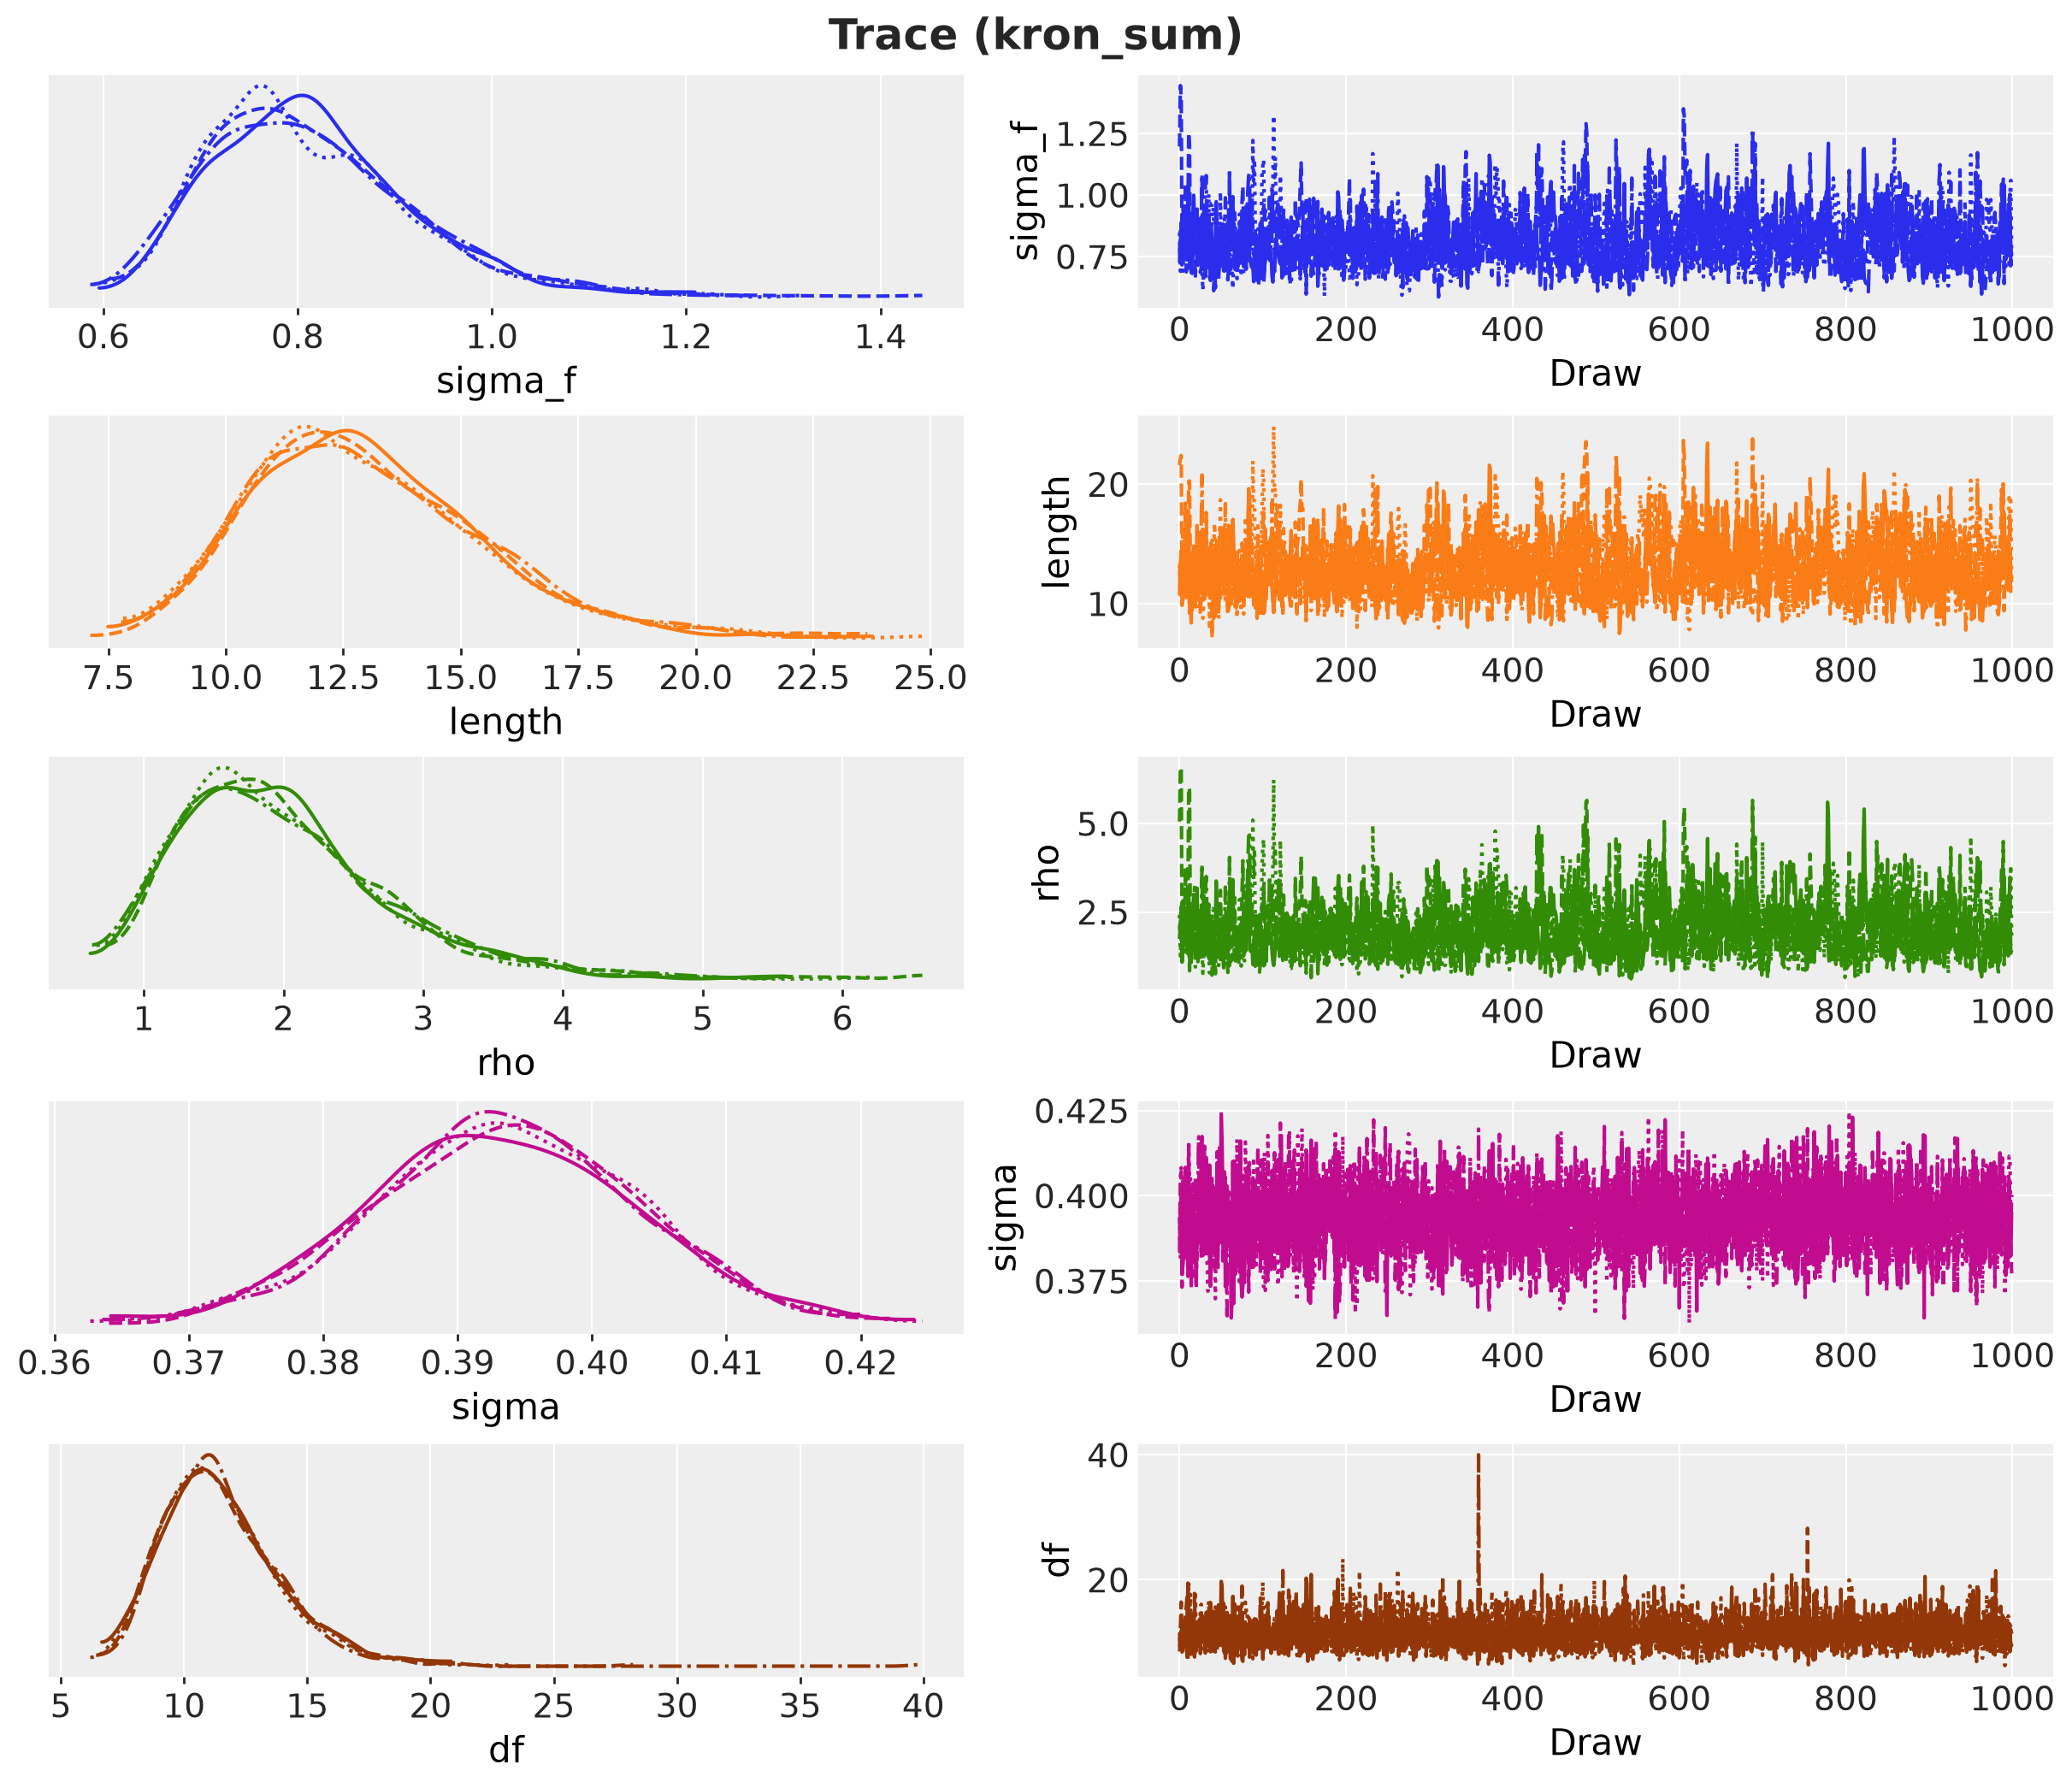

In [24]:
pc = az.plot_trace_dist(
    idatas["kron_sum"], var_names=hyper_names, figure_kwargs={"figsize": (12, 10)}
)
pc.viz["figure"].item().suptitle(
    "Trace (kron_sum)", fontsize=18, fontweight="bold", y=1.03
);

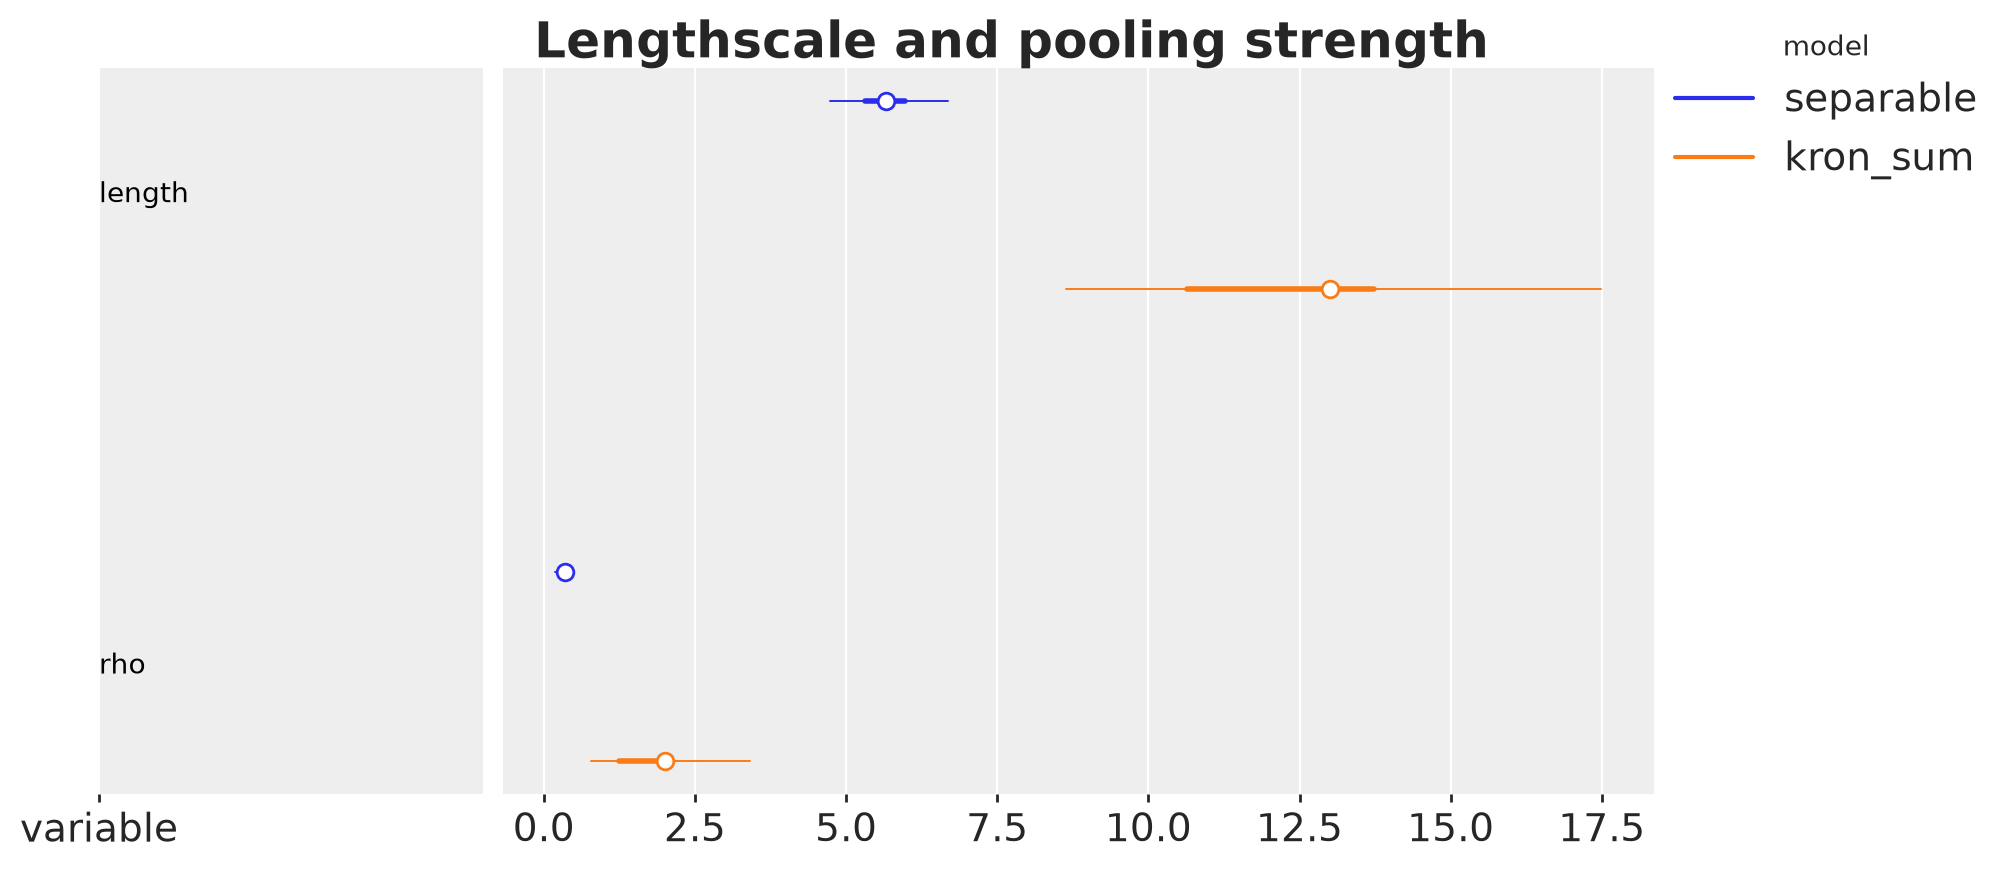

In [25]:
pc = az.plot_forest(
    {"separable": idatas["separable"], "kron_sum": idatas["kron_sum"]},
    var_names=["length", "rho"],
    combined=True,
    figure_kwargs={"figsize": (10, 4)},
)
pc.add_legend("model")
pc.viz["figure"].item().suptitle(
    "Lengthscale and pooling strength", fontsize=18, fontweight="bold", y=1.05
);

### Basis Size Check

We now check the basis size rule against the posterior of the Kronecker-sum model. We compute the effective lengthscale of each graph mode at the posterior median.

In [26]:
posterior_kron = mcmcs["kron_sum"].get_samples()
length_hat = float(jnp.median(posterior_kron["length"]))
rho_hat = float(jnp.median(posterior_kron["rho"]))
ell_post = np.asarray(effective_lengthscales(mu_j, length_hat, rho_hat))
m_rule_post = 1.75 * C_BOX * (DURATION / 2) / ell_post.min()

print(f"posterior median: length = {length_hat:.1f} weeks, rho = {rho_hat:.2f}")
print(
    f"effective lengthscales: {ell_post[0]:.1f} (national) to {ell_post[-1]:.1f} weeks"
)
print(f"basis size rule: m >= {m_rule_post:.0f} (we used m = {M_BASIS})")

posterior median: length = 12.7 weeks, rho = 1.87
effective lengthscales: 12.7 (national) to 2.8 weeks
basis size rule: m >= 78 (we used m = 48)


The rule asks for more basis functions than we used, so the roughest modes are under-resolved. We refit the Kronecker-sum model with $m = 96$ and compare the hyperparameters and the forecast scores below. If the posterior of $\rho$ moves down with the larger basis, the truncation was acting as extra pooling.

In [27]:
M_LARGE = 96
models["kron_sum_m96"] = make_model(
    mu_j, U_j, mode="kron_sum", duration=DURATION, m=M_LARGE
)

rng_key, rng_subkey = random.split(rng_key)
t_start = time.time()
mcmcs["kron_sum_m96"] = fit_nuts(
    rng_subkey, models["kron_sum_m96"], covariates_train, y_train
)
idatas["kron_sum_m96"] = az.from_numpyro(mcmcs["kron_sum_m96"])
print(f"kron_sum with m = {M_LARGE} fitted in {time.time() - t_start:.0f} s")

pl.from_pandas(
    az.summary(
        idatas["kron_sum_m96"], var_names=hyper_names, ci_prob=HDI_PROB, ci_kind="hdi"
    ).reset_index(names="parameter")
)

kron_sum with m = 96 fitted in 26 s


parameter,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sigma_f""",0.732202,0.06909,0.632949,0.887285,739.315537,1158.624127,1.002258,0.002622,0.002601
"""length""",9.331239,1.457155,7.149879,12.529107,701.643886,1205.069096,1.000643,0.056503,0.053182
"""rho""",1.121527,0.421023,0.560569,2.088665,673.508326,1158.129072,1.001566,0.016824,0.018698
"""sigma""",0.355169,0.010992,0.334444,0.375821,2004.522644,2955.118893,1.000447,0.000245,0.000169
"""df""",9.740227,2.109453,6.704788,14.390342,3492.167493,3069.371655,1.000074,0.037122,0.035764


With the larger basis the posterior of $\rho$ moves down and $\ell$ gets shorter: part of the pooling in the $m = 48$ fit came from the truncation, which could not represent the fast regional deviations and pushed them into the shared trend and into the noise. We keep both fits and score them below.

## Forecasts

The `forecast` function of `numpyro-forecast` runs the model with the full covariates and the training data: the in-sample sites come from the posterior and the forecast suffix is sampled at `obs_future`. We pass only the latent sites of the posterior (not the deterministic `gp_f`, whose in-sample shape would not match the full horizon).

In [28]:
LATENT_SITES = [
    "sigma_f",
    "length",
    "rho",
    "gp_beta",
    "intercept",
    "w_seas",
    "sigma",
    "df",
]

forecasts: dict[str, Array] = {}
for name, mcmc in mcmcs.items():
    posterior = {k: v for k, v in mcmc.get_samples().items() if k in LATENT_SITES}
    rng_key, rng_subkey = random.split(rng_key)
    forecasts[name] = forecast(
        rng_subkey, models[name], posterior, y_train, covariates
    )  # (draws, H, R)

print({name: tuple(v.shape) for name, v in forecasts.items()})

{'independent': (4000, 13, 16), 'separable': (4000, 13, 16), 'kron_sum': (4000, 13, 16), 'kron_sum_m96': (4000, 13, 16)}


We plot the forecasts for four regions: a hub (NI), a leaf (HB), and two states in the east and the south (SN, BY). The bands are the central $94\%$ intervals of the forecast draws.

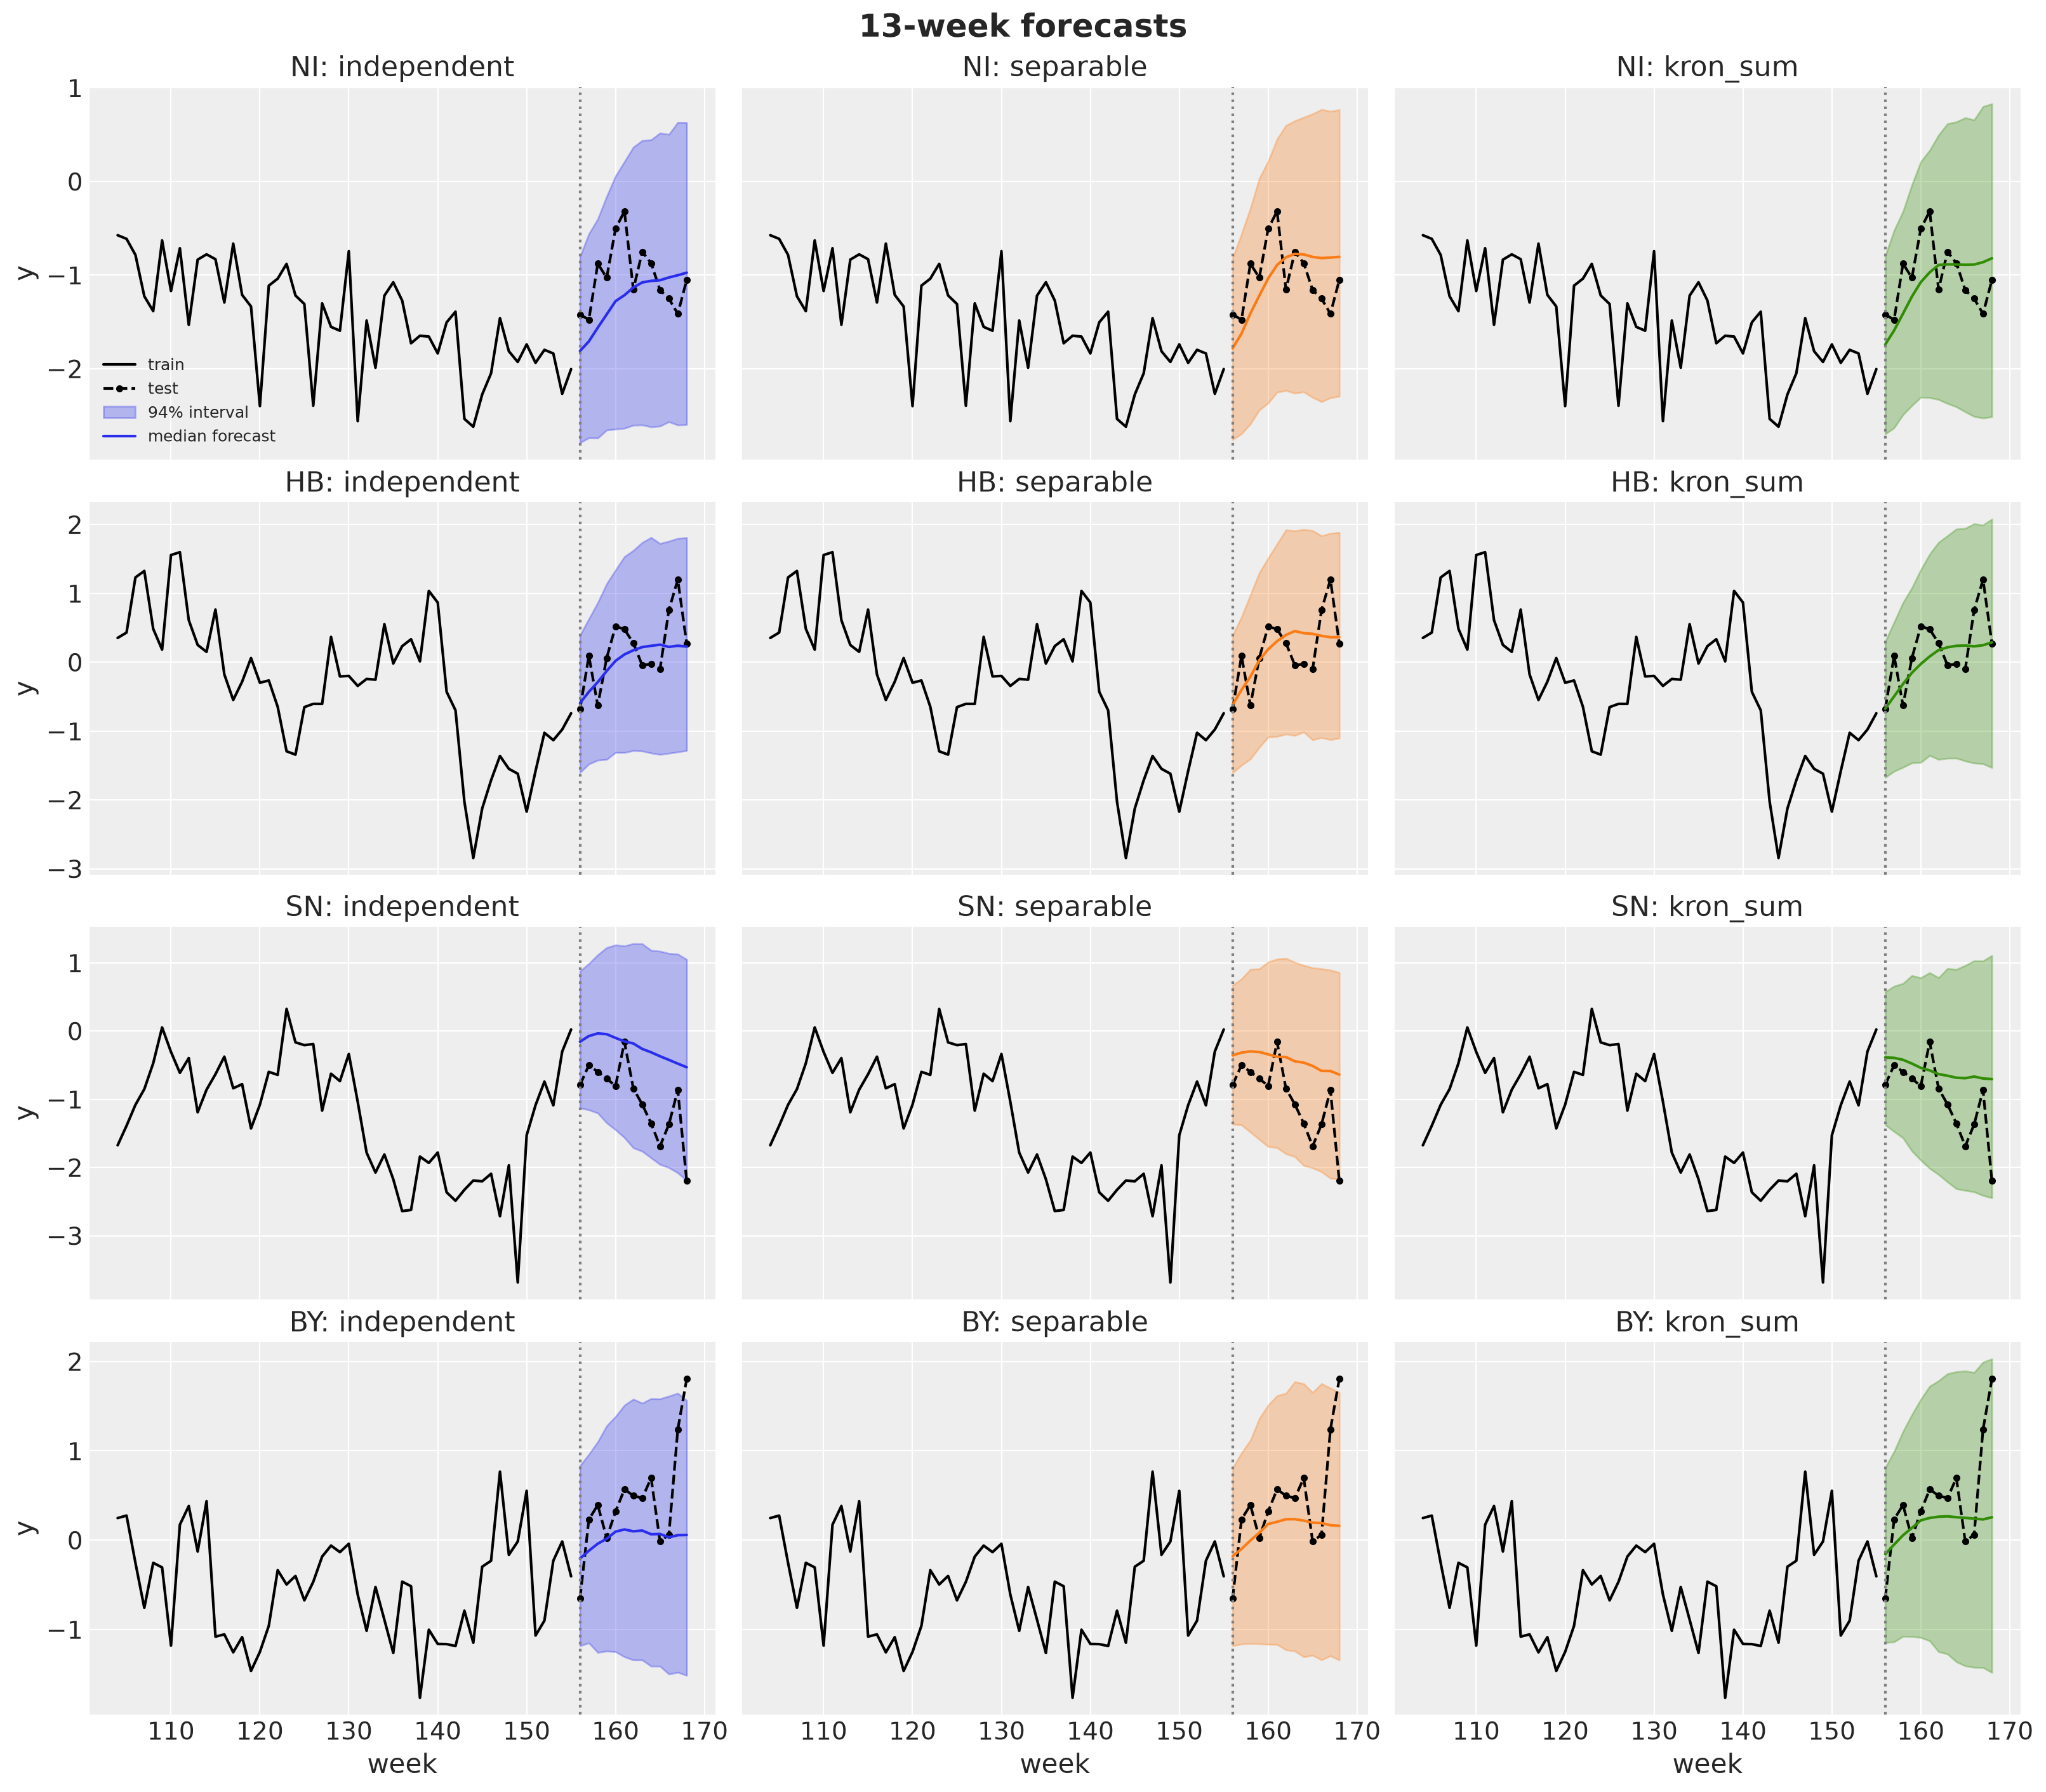

In [29]:
def plot_forecast_panel(
    forecasts: dict[str, Array], names: list[str], regions: list[str], history: int = 52
) -> None:
    fig, axes = plt.subplots(
        nrows=len(regions),
        ncols=len(names),
        figsize=(16, 3.5 * len(regions)),
        sharex=True,
        sharey="row",
        layout="constrained",
    )
    t_hist = np.arange(T_OBS - history, T_OBS)
    t_fut = np.arange(T_OBS, DURATION)
    for row, region in enumerate(regions):
        r = state_index[region]
        for col, name in enumerate(names):
            ax = axes[row, col]
            ax.plot(
                t_hist, np.asarray(y_train[-history:, r]), color="black", label="train"
            )
            ax.plot(
                t_fut,
                np.asarray(y_test[:, r]),
                color="black",
                linestyle="--",
                marker="o",
                markersize=3,
                label="test",
            )
            draws = np.asarray(forecasts[name][:, :, r])
            lower, upper = np.quantile(
                draws, [(1 - HDI_PROB) / 2, 1 - (1 - HDI_PROB) / 2], axis=0
            )
            ax.fill_between(
                t_fut,
                lower,
                upper,
                color=f"C{col}",
                alpha=0.3,
                label=f"{HDI_PROB:.0%} interval",
            )
            ax.plot(
                t_fut,
                np.median(draws, axis=0),
                color=f"C{col}",
                label="median forecast",
            )
            ax.axvline(x=T_OBS, color="gray", linestyle=":")
            ax.set(title=f"{region}: {name}")
        axes[row, 0].set(ylabel="y")
    axes[0, 0].legend(loc="lower left", fontsize=9)
    for ax in axes[-1]:
        ax.set(xlabel="week")
    fig.suptitle("13-week forecasts", fontsize=18, fontweight="bold")


plot_forecast_panel(forecasts, names=MODES, regions=["NI", "HB", "SN", "BY"]);

## Forecast Evaluation

We score the forecast panel with the CRPS (lower is better), the RMSE of the mean forecast, and the empirical coverage of the central $90\%$ interval. We also report the CRPS on the last four weeks of the horizon, where spatial pooling should matter most.

In [30]:
def score(samples: Array, truth: Array) -> dict[str, float]:
    return {
        "crps": float(eval_crps(samples, truth)),
        "crps_h10_13": float(eval_crps(samples[:, -4:], truth[-4:])),
        "rmse": float(eval_rmse(samples, truth)),
        "coverage_90": float(eval_coverage(samples, truth, alpha=0.9)),
    }


scores = pl.DataFrame(
    [
        {
            "model": name,
            **score(samples, y_test),
            "length": float(jnp.median(mcmcs[name].get_samples()["length"])),
            "rho": float(jnp.median(mcmcs[name].get_samples()["rho"]))
            if "rho" in mcmcs[name].get_samples()
            else None,
        }
        for name, samples in forecasts.items()
    ]
)
scores

model,crps,crps_h10_13,rmse,coverage_90,length,rho
str,f64,f64,f64,f64,f64,f64
"""independent""",0.352192,0.408401,0.625092,0.947115,7.657252,null
"""separable""",0.344726,0.401588,0.613294,0.942308,5.649794,0.338743
"""kron_sum""",0.335115,0.399854,0.587805,0.951923,12.68804,1.868685
"""kron_sum_m96""",0.329663,0.400441,0.581713,0.951923,9.121078,1.043614


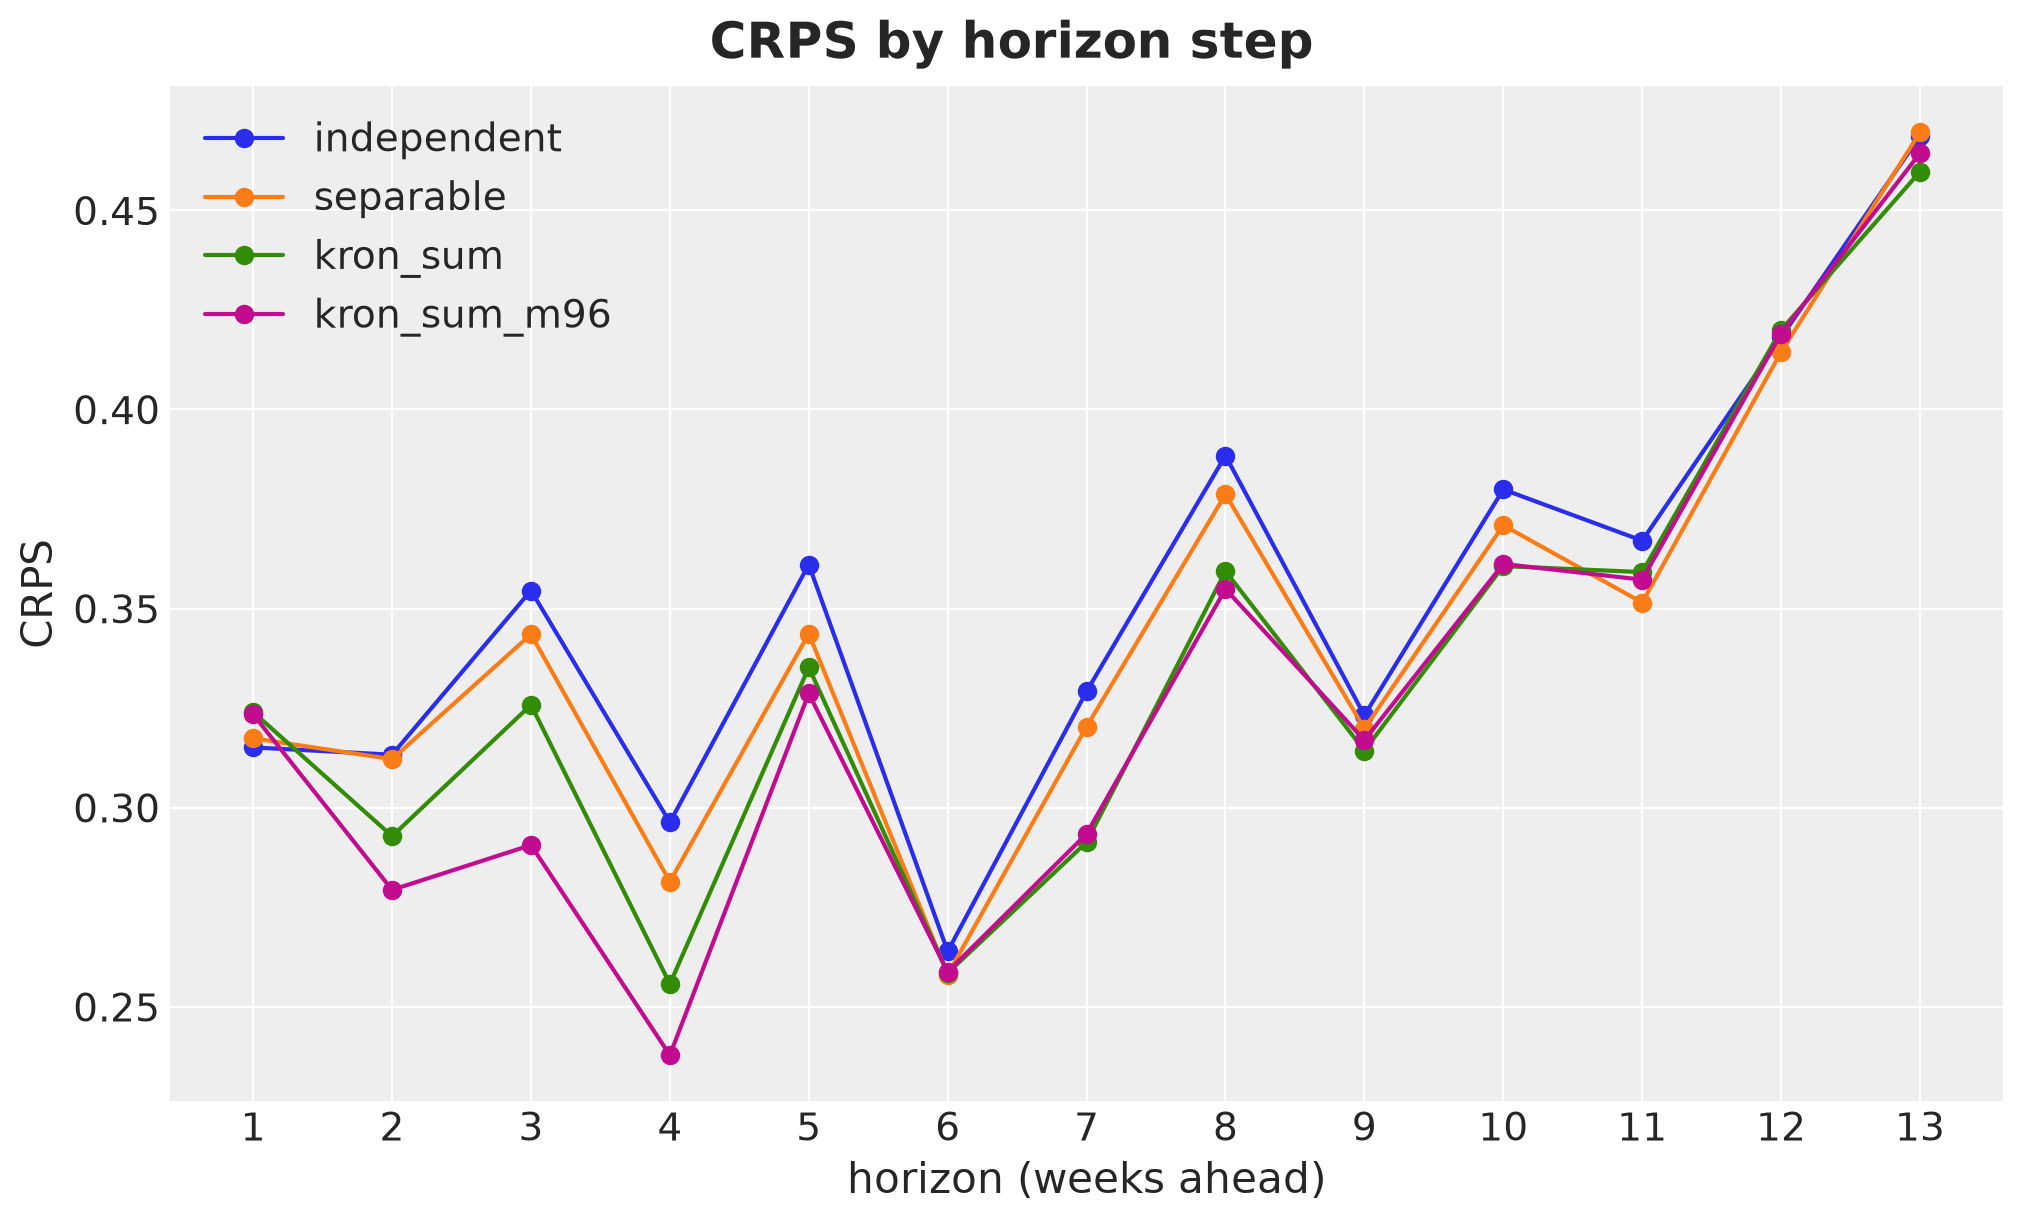

In [31]:
crps_by_h = {
    name: np.array([float(eval_crps(samples[:, h], y_test[h])) for h in range(H)])
    for name, samples in forecasts.items()
}

fig, ax = plt.subplots()
for i, name in enumerate(forecasts):
    ax.plot(np.arange(1, H + 1), crps_by_h[name], marker="o", color=f"C{i}", label=name)
ax.set(xlabel="horizon (weeks ahead)", ylabel="CRPS", xticks=np.arange(1, H + 1))
ax.legend()
fig.suptitle("CRPS by horizon step", fontsize=18, fontweight="bold");

On this split the differences are small. The Kronecker-sum model has the lowest CRPS over the panel, the larger basis helps a little more, and the ranking changes from one horizon step to the next. A single split is one draw of a noisy statistic, so we run a backtest below. Before that we look at the spatial structure of the forecasts, which is where the three priors differ by construction.

### Spatial Structure of the Forecasts

The three priors differ in how the forecast of one region is tied to the forecast of its neighbors. We compute, at every horizon step, the correlation across forecast draws between pairs of regions, and we average it over adjacent and over non-adjacent pairs. Close to the data every forecast is pinned down by the observations, so all correlations start near zero. As the horizon grows, the shared components of the uncertainty take over, and the shape of that growth is the signature of each prior.

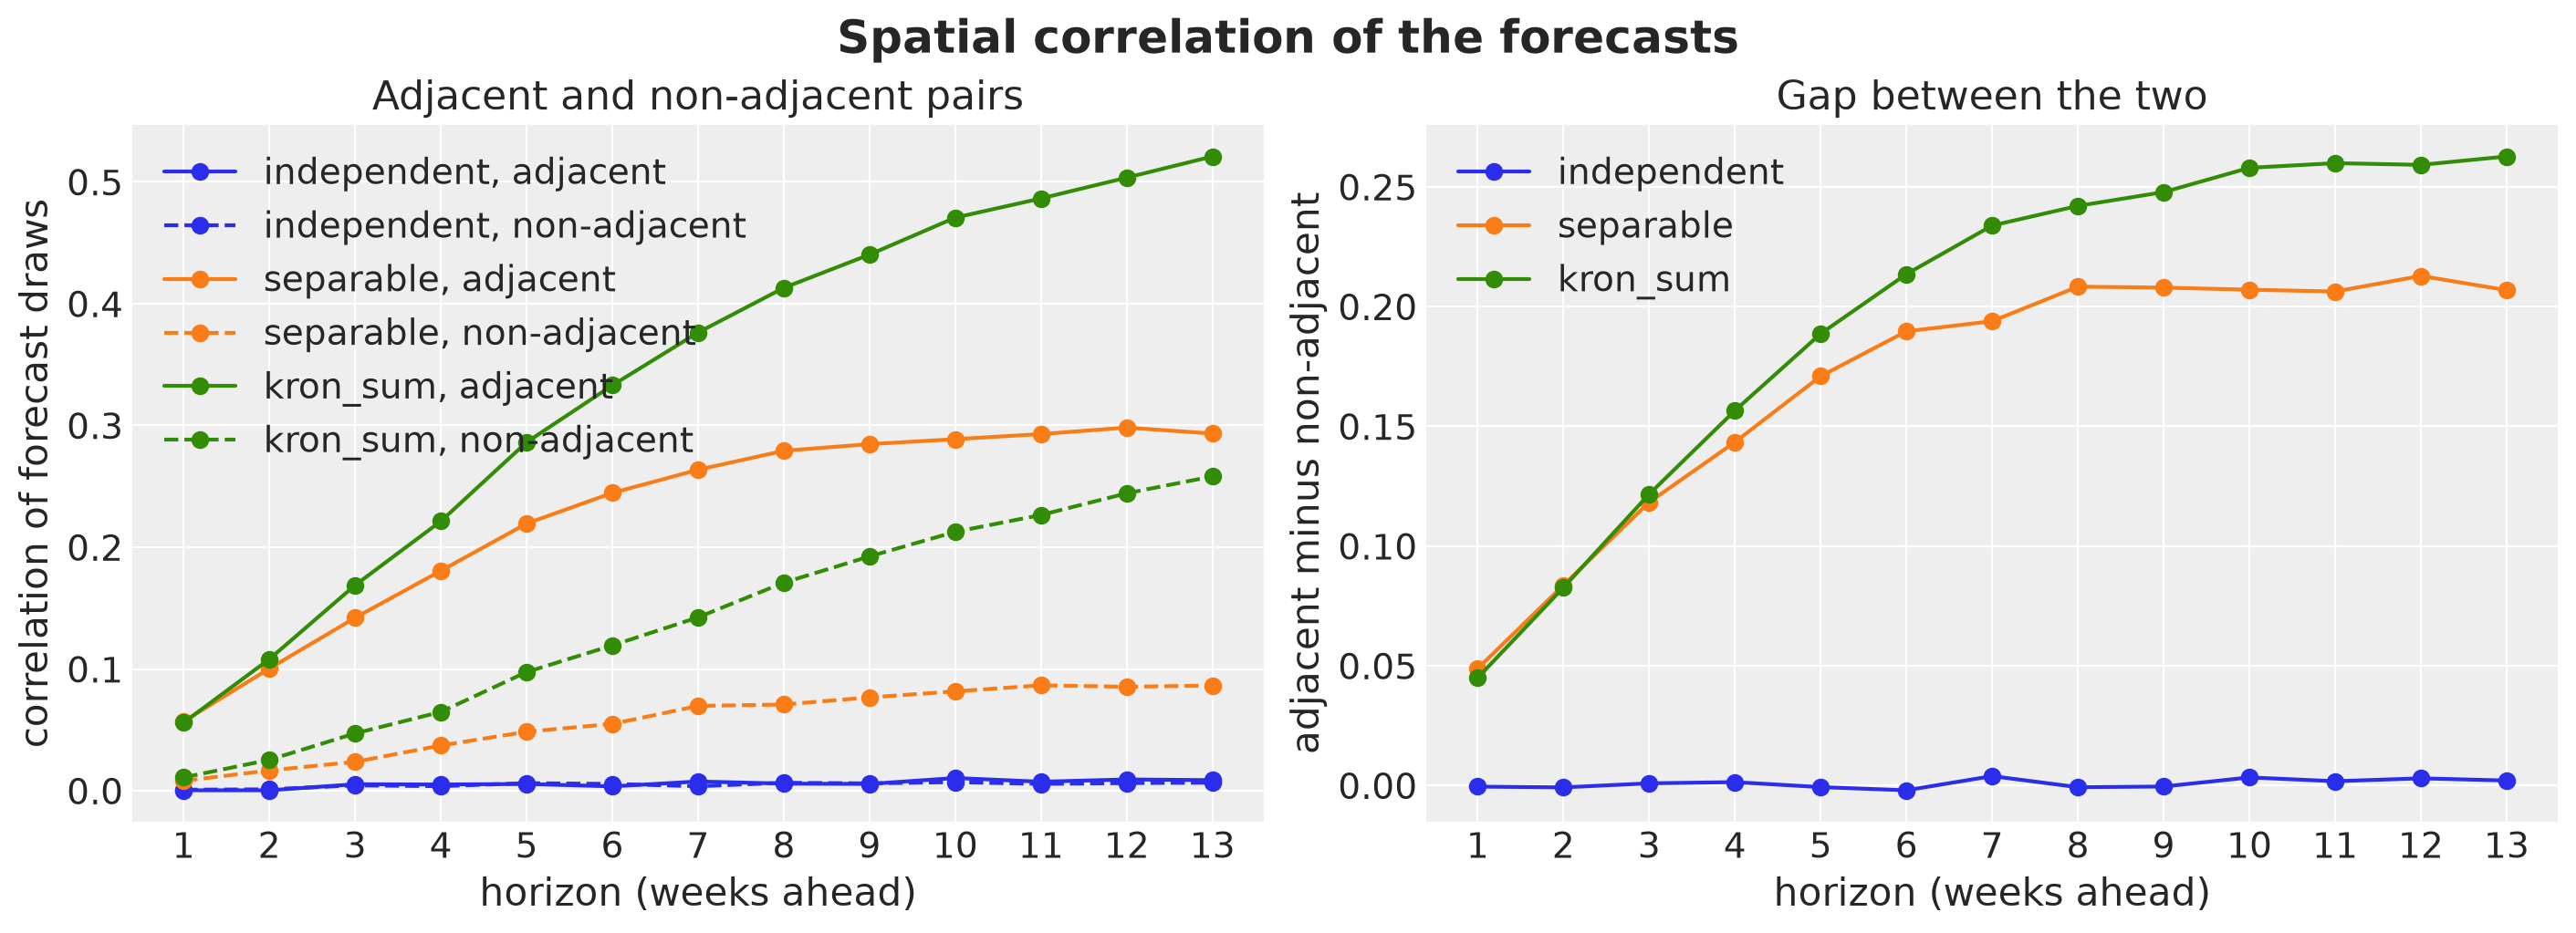

In [32]:
def spatial_correlation(samples: Array) -> dict[str, np.ndarray]:
    "Mean correlation across draws for adjacent and non-adjacent regions, per horizon."
    out = {"adjacent": [], "non-adjacent": []}
    for h in range(samples.shape[1]):
        corr = np.corrcoef(np.asarray(samples[:, h, :]).T)
        out["adjacent"].append(corr[adjacent].mean())
        out["non-adjacent"].append(corr[non_adjacent].mean())
    return {k: np.array(v) for k, v in out.items()}


spatial_corr = {name: spatial_correlation(forecasts[name]) for name in MODES}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for i, name in enumerate(MODES):
    axes[0].plot(
        np.arange(1, H + 1),
        spatial_corr[name]["adjacent"],
        color=f"C{i}",
        marker="o",
        label=f"{name}, adjacent",
    )
    axes[0].plot(
        np.arange(1, H + 1),
        spatial_corr[name]["non-adjacent"],
        color=f"C{i}",
        marker="o",
        linestyle="--",
        label=f"{name}, non-adjacent",
    )
    axes[1].plot(
        np.arange(1, H + 1),
        spatial_corr[name]["adjacent"] - spatial_corr[name]["non-adjacent"],
        color=f"C{i}",
        marker="o",
        label=name,
    )
axes[0].set(
    xlabel="horizon (weeks ahead)",
    ylabel="correlation of forecast draws",
    title="Adjacent and non-adjacent pairs",
    xticks=np.arange(1, H + 1),
)
axes[0].legend()
axes[1].set(
    xlabel="horizon (weeks ahead)",
    ylabel="adjacent minus non-adjacent",
    title="Gap between the two",
    xticks=np.arange(1, H + 1),
)
axes[1].legend()
fig.suptitle("Spatial correlation of the forecasts", fontsize=18, fontweight="bold");

For the independent model the only shared components are the seasonal weights, so both curves stay near zero. For the separable model the correlations saturate after about eight weeks, with adjacent pairs at about $0.3$ and non-adjacent pairs below $0.1$: the spatial pattern of the forecast uncertainty is fixed. For the Kronecker sum the correlations keep growing over the whole horizon, for adjacent *and* for non-adjacent pairs. The smooth spatial modes and the national mode have the longest memory, so the further we forecast, the more the regional forecasts move as one block around the national forecast. Within 13 weeks the non-adjacent correlation of the Kronecker sum is close to the adjacent correlation of the separable model.

## Rolling-Origin Backtest

We use `backtest` from `numpyro-forecast` with six expanding windows, a 13-week test window, and a stride of four weeks. The `forecast_fn` closure fits the model with NUTS on the training window and forecasts the test window. Since the box of every model covers the full duration, the same factory serves every window: each call only sees a shorter prefix of the basis.

In [33]:
def forecast_fn(
    rng_key,
    model,
    train_data,
    train_covariates,
    full_covariates,
    num_samples,
    *,
    batch_size=None,
):
    k_fit, k_fc = random.split(rng_key)
    mcmc = fit_nuts(
        k_fit,
        model,
        train_covariates,
        train_data,
        num_warmup=500,
        num_samples=num_samples // 4,
    )  # 4 chains
    posterior = {k: v for k, v in mcmc.get_samples().items() if k in LATENT_SITES}
    return forecast(
        k_fc, model, posterior, train_data, full_covariates, batch_size=batch_size
    )


backtest_results = {}
for mode in MODES:
    rng_key, rng_subkey = random.split(rng_key)
    t_start = time.time()
    backtest_results[mode] = backtest(
        rng_subkey,
        y,
        covariates,
        lambda mode=mode: make_model(mu_j, U_j, mode=mode, duration=DURATION),
        forecast_fn=forecast_fn,
        metrics={"crps": eval_crps, "rmse": eval_rmse, "coverage_90": eval_coverage},
        min_train_window=DURATION - H - 5 * 4,
        test_window=H,
        stride=4,
        num_samples=1_000,
    )
    n_windows = len(backtest_results[mode])
    print(f"{mode:12s} backtest ({n_windows} windows) in {time.time() - t_start:.0f} s")

independent  backtest (6 windows) in 44 s


separable    backtest (6 windows) in 54 s


kron_sum     backtest (6 windows) in 79 s


In [34]:
backtest_df = pl.DataFrame(
    [
        {"model": mode, "window": i, "t1": res.t1, **res.metrics}
        for mode, results in backtest_results.items()
        for i, res in enumerate(results)
    ]
)

backtest_summary = backtest_df.group_by("model", maintain_order=True).agg(
    pl.col("crps").mean().alias("crps_mean"),
    pl.col("rmse").mean().alias("rmse_mean"),
    pl.col("coverage_90").mean().alias("coverage_90_mean"),
)
backtest_summary

model,crps_mean,rmse_mean,coverage_90_mean
str,f64,f64,f64
"""independent""",0.412937,0.734711,0.911058
"""separable""",0.403339,0.718173,0.914263
"""kron_sum""",0.374928,0.664902,0.9375


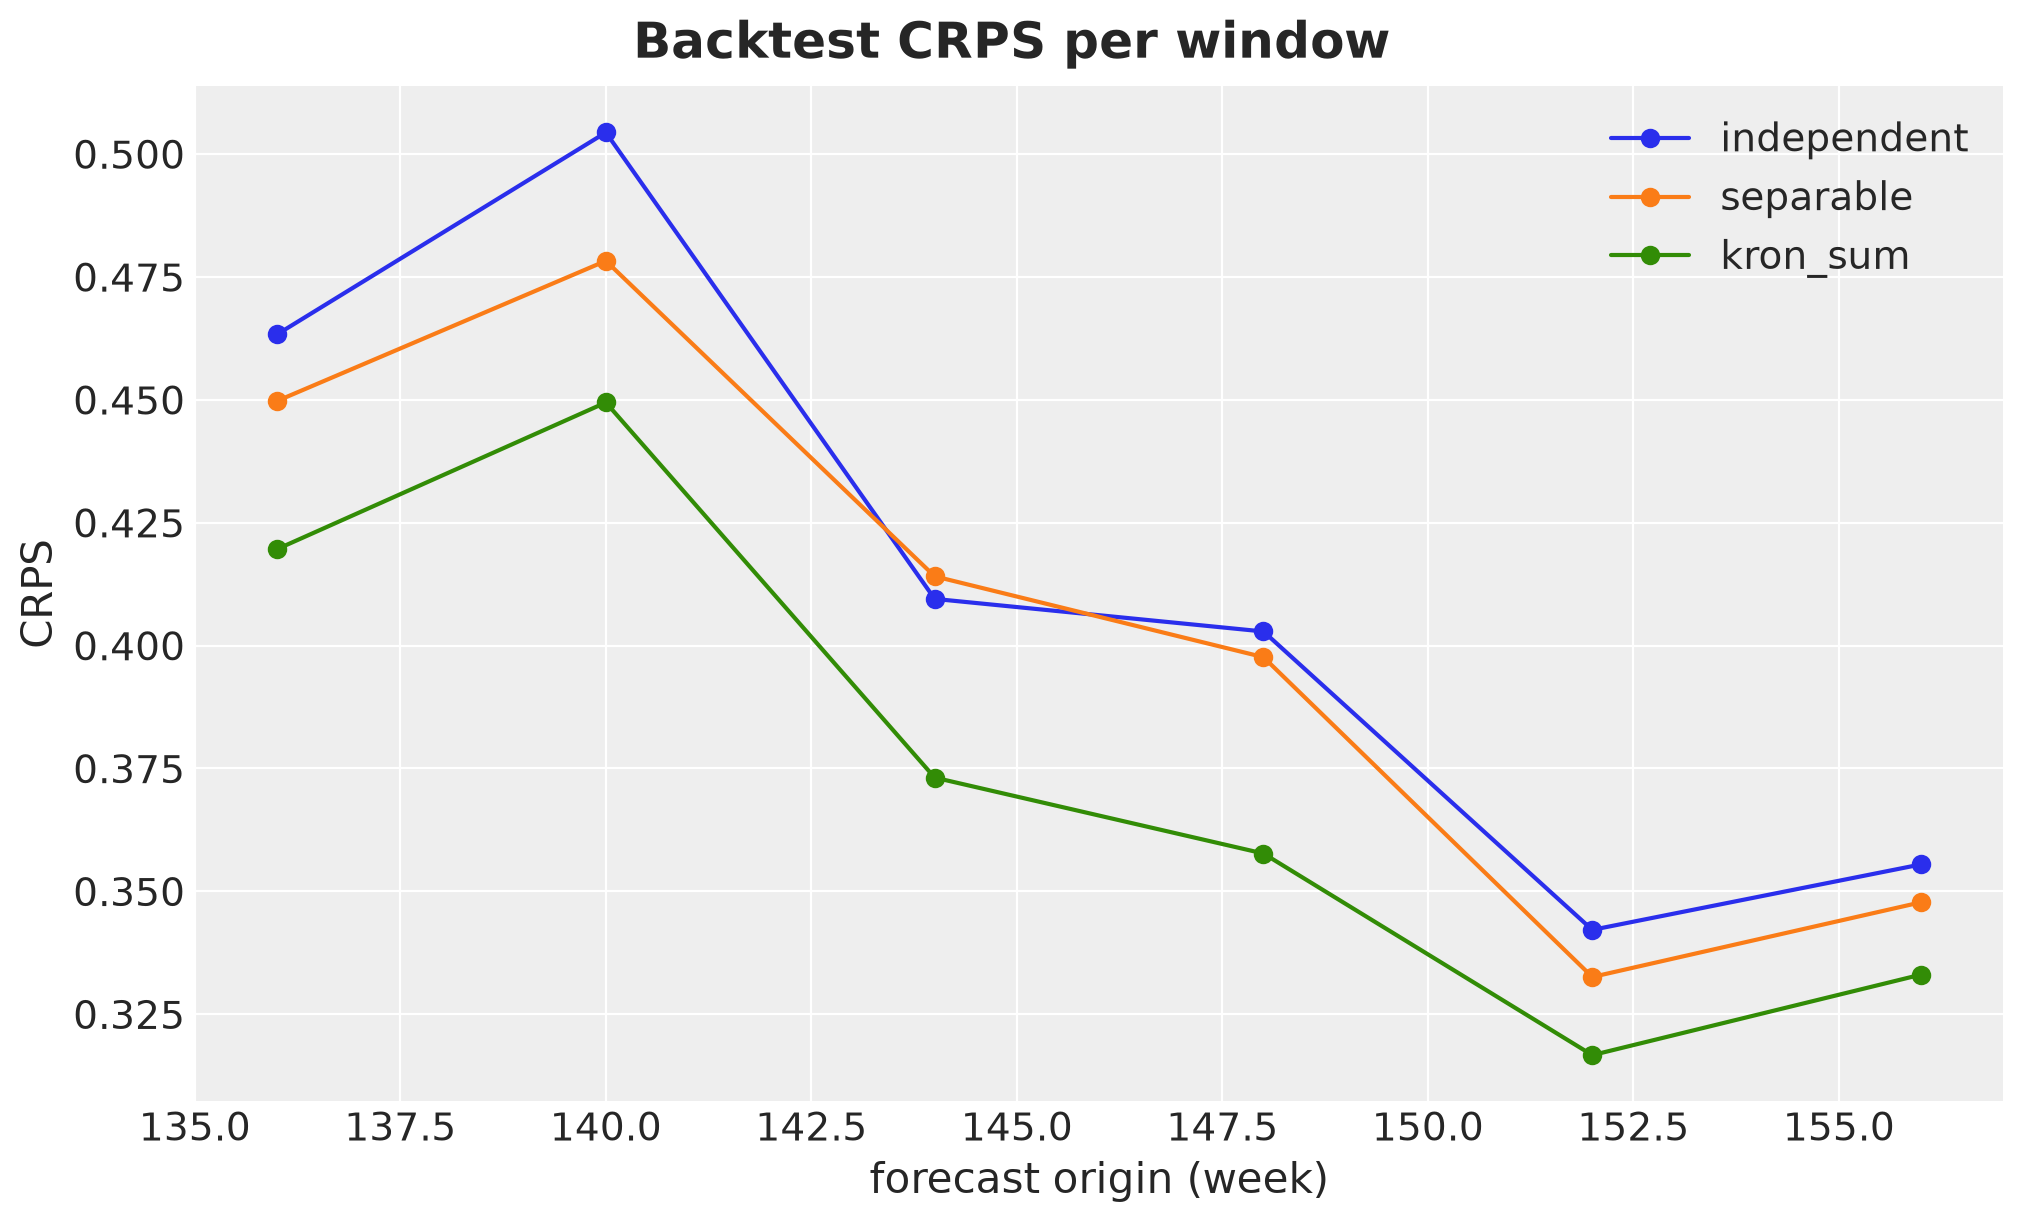

In [35]:
fig, ax = plt.subplots()
for i, mode in enumerate(MODES):
    sel = backtest_df.filter(pl.col("model") == mode)
    ax.plot(sel["t1"], sel["crps"], marker="o", color=f"C{i}", label=mode)
ax.set(xlabel="forecast origin (week)", ylabel="CRPS")
ax.legend()
fig.suptitle("Backtest CRPS per window", fontsize=18, fontweight="bold");

The paired differences per window are the honest summary: the same window, the same data, only the prior changes.

In [36]:
paired = (
    backtest_df.pivot(on="model", index="window", values="crps")
    .with_columns(
        (pl.col("kron_sum") - pl.col("separable")).alias("kron_sum - separable"),
        (pl.col("kron_sum") - pl.col("independent")).alias("kron_sum - independent"),
        (pl.col("separable") - pl.col("independent")).alias("separable - independent"),
    )
    .select("kron_sum - separable", "kron_sum - independent", "separable - independent")
)

paired.describe().filter(pl.col("statistic").is_in(["mean", "std", "min", "max"]))

statistic,kron_sum - separable,kron_sum - independent,separable - independent
str,f64,f64,f64
"""mean""",-0.028411,-0.038009,-0.009598
"""std""",0.011291,0.01243,0.010125
"""min""",-0.040948,-0.054933,-0.02612
"""max""",-0.014717,-0.022421,0.004592


## Conclusion

We built a non-separable Gaussian process on the product space *interval times graph* from the eigenpairs of a Kronecker-sum Laplacian. The construction keeps everything that makes the HSGP approximation practical: the basis is fixed and hyperparameter-free, the weights are diagonal, and the latent panel is two matrix multiplications. The modeling content is in one scalar, the pooling strength $\rho$: rough spatial patterns get a shorter temporal memory and a smaller amplitude than the national trend, and the graph decides which patterns are suppressed first.

Four checks come with the construction and we recommend all of them:

- Trace normalization fixes the scale, and node standardization removes the variance heterogeneity that an irregular graph induces. Without it, low-degree regions get much wider prior bands for no modeling reason.
- The basis size must resolve the *shortest* effective lengthscale $\ell / \sqrt{1 + \rho \mu_{\max}}$. Print it from the posterior. A too-small basis acts as extra pooling.
- The time box must be fixed from the full duration, not from the length of the current call, so that training and forecasting share the same basis.
- Compare against the separable and the independent priors with the same hyperparameters, and do it on a backtest. On this synthetic panel the Kronecker sum has the lowest CRPS in every window, but the gain is modest (a few percent) and the data generating process is a diffusion on the same graph. If the gain does not show on real data, the honest conclusion is that the separable prior is enough.

The same structure extends to a periodic time Laplacian (a seasonality that is shared nationally but blurred regionally), to three factors (interval times region graph times product graph), and to a fractional graph exponent that decouples the spatial from the temporal smoothness. What does not keep the structure is learning the graph weights: the basis would then depend on parameters and the eigendecomposition would move inside the model.

## References

- Riutort-Mayol, G., Bürkner, P.-C., Andersen, M. R., Solin, A., and Vehtari, A. (2023). [Practical Hilbert space approximate Bayesian Gaussian processes for probabilistic programming](https://link.springer.com/article/10.1007/s11222-022-10167-2). *Statistics and Computing*, 33, 17.
- Solin, A. and Särkkä, S. (2020). [Hilbert space methods for reduced-rank Gaussian process regression](https://link.springer.com/article/10.1007/s11222-019-09886-w). *Statistics and Computing*, 30, 419-446.
- Borovitskiy, V., Azangulov, I., Terenin, A., Mostowsky, P., Deisenroth, M. P., and Durrande, N. (2021). [Matérn Gaussian Processes on Graphs](https://proceedings.mlr.press/v130/borovitskiy21a.html). *AISTATS 2021*.
- Orduz, J. (2024). [A Conceptual and Practical Introduction to Hilbert Space GPs Approximation Methods](https://juanitorduz.github.io/hsgp_intro/).
- Orduz, J. (2020). [Spectral Clustering](https://juanitorduz.github.io/spectral_clustering/).
- [numpyro-forecast](https://github.com/juanitorduz/numpyro_forecast): forecasting building blocks, predictive helpers, and backtesting for NumPyro.
- [NumPyro HSGP module](https://num.pyro.ai/en/stable/contrib.html#hilbert-space-gaussian-processes-approximation): `numpyro.contrib.hsgp`.